# Laptop Price Prediction - Regression Track (Algorithms 1-10)

## Scope of this notebook

This notebook implements the **all ten algorithms** required for the capstone project:

1. **Linear Regression**
2. **Ridge Regression**
3. **Lasso Regression**
4. **ElasticNet Regression**
5. **Polynomial Regression**
6. **Decision Tree Regressor**
7. **Random Forest Regressor**
8. **Gradient Boosting Regressor**
9. **Support Vector Regressor**
10. **K-Nearest Neighbours Regressor**

## 1. Why the preprocessing notebook is kept separate

The raw laptop data is transformed in a separate preprocessing notebook, and its final output is saved as `regression.csv`. Keeping that stage separate makes the modelling workflow easier to follow: this notebook starts from the prepared regression representation and concentrates on exploratory analysis, train/test separation, model fitting, comparison, tuning, and diagnostics.

The regression notebook therefore treats `regression.csv` as its modelling input. Only transformations that belong to the modelling stage, such as scaling learned from the training data, are performed here.

In [3]:
# Core Python libraries
import os
import warnings
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

# Reproducibility requirement from the capstone guidelines
RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Libraries imported successfully.")
print("Random state:", RANDOM_STATE)

Libraries imported successfully.
Random state: 42


## 2. Load the preprocessed regression dataset

The file `regression.csv` contains the numerical and encoded predictor variables together with the continuous target `price`. The raw file is deliberately not loaded in this notebook because raw-data cleaning and feature construction have already been handled in the dedicated preprocessing stage.

The first check is still performed here because model training should always begin with an audit of the exact data representation that enters the estimators. This lets us verify the dimensions, data types, missing values, duplicate representation, and target scale before any train/test split is created.

In [4]:
df = pd.read_csv("data/regression.csv")


print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (1243, 43)


,inches,ram,weight,is_ips,is_touchscreen,res_width,res_height,storage_gb,has_ssd,has_hdd,ppi,company_Apple,company_Asus,company_Chuwi,company_Dell,company_Fujitsu,company_Google,company_Hp,company_Huawei,company_Lenovo,company_Lg,company_Mediacom,company_Microsoft,company_Msi,company_Razer,company_Samsung,company_Toshiba,company_Vero,company_Xiaomi,typename_Gaming,typename_Netbook,typename_Notebook,typename_Ultrabook,typename_Workstation,opsys_Chrome Os,opsys_Linux,opsys_Mac Os X,opsys_Macos,opsys_No Os,opsys_Windows 10,opsys_Windows 10 S,opsys_Windows 7,price
0,13.3000,8.0000,1.3700,1,0,2560,1600,128.0000,1,0,226.9830,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,"71,378.6832"
1,13.3000,8.0000,1.3400,0,0,1440,900,128.0000,0,0,127.6779,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,"47,895.5232"
2,15.6000,8.0000,1.8600,0,0,1920,1080,256.0000,1,0,141.2120,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,"30,636.0000"
3,15.4000,16.0000,1.8300,1,0,2880,1800,512.0000,1,0,220.5346,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,"135,195.3360"
4,13.3000,8.0000,1.3700,1,0,2560,1600,256.0000,1,0,226.9830,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,"96,095.8080"


## 3. Dataset audit

The audit establishes what the regression models actually receive. The prepared dataset contains **1,243 observations and 42 predictor columns**, with `price` as the continuous response variable.

The data types are important because scikit-learn's regression estimators ultimately operate on numerical matrices. The categorical information has already been represented through encoded indicator columns, while variables such as `ram`, `storage_gb`, `ppi`, and screen dimensions remain numeric.

We also check for missing values and exact duplicates in the final modelling representation. A duplicate at this stage means two rows are identical after preprocessing; it does not necessarily mean that the corresponding raw laptop records were identical.

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame(name="dtype"))

print("\nMissing values by column:")
missing_table = df.isna().sum().to_frame(name="missing_values")
missing_table["missing_percentage"] = 100 * missing_table["missing_values"] / len(df)
display(missing_table)

print("\nDuplicate rows in the final encoded representation:", df.duplicated().sum())

if "price" not in df.columns:
    raise KeyError("The expected regression target column 'price' is missing.")

print("\nTarget summary:")
display(df["price"].describe().to_frame().T)

Number of rows: 1243
Number of columns: 43

Column names:
['inches', 'ram', 'weight', 'is_ips', 'is_touchscreen', 'res_width', 'res_height', 'storage_gb', 'has_ssd', 'has_hdd', 'ppi', 'company_Apple', 'company_Asus', 'company_Chuwi', 'company_Dell', 'company_Fujitsu', 'company_Google', 'company_Hp', 'company_Huawei', 'company_Lenovo', 'company_Lg', 'company_Mediacom', 'company_Microsoft', 'company_Msi', 'company_Razer', 'company_Samsung', 'company_Toshiba', 'company_Vero', 'company_Xiaomi', 'typename_Gaming', 'typename_Netbook', 'typename_Notebook', 'typename_Ultrabook', 'typename_Workstation', 'opsys_Chrome Os', 'opsys_Linux', 'opsys_Mac Os X', 'opsys_Macos', 'opsys_No Os', 'opsys_Windows 10', 'opsys_Windows 10 S', 'opsys_Windows 7', 'price']

Data types:


,dtype
inches,float64
ram,float64
weight,float64
is_ips,int64
is_touchscreen,int64
res_width,int64
res_height,int64
storage_gb,float64
has_ssd,int64
has_hdd,int64



Missing values by column:


,missing_values,missing_percentage
inches,0,0.0000
ram,0,0.0000
weight,0,0.0000
is_ips,0,0.0000
is_touchscreen,0,0.0000
res_width,0,0.0000
res_height,0,0.0000
storage_gb,0,0.0000
has_ssd,0,0.0000
has_hdd,0,0.0000



Duplicate rows in the final encoded representation: 2

Target summary:


,count,mean,std,min,25%,50%,75%,max
price,"1,243.0000","59,737.1652","34,344.3636","9,270.7200","32,650.2504","52,693.9200","79,733.5200","150,358.4244"


### Audit interpretation

The audit shows a **complete modelling table**: every predictor and the `price` target has zero missing values. This means the regression estimators do not need an additional missing-value treatment at the modelling stage.

There are **2 exact duplicate rows** in the final encoded representation. Because preprocessing is kept as a separate stage and this notebook is focused on model comparison, those rows are reported rather than silently removed here.

The target is clearly continuous, ranging from **9,270.72** to **150,358.42**, with a mean of **59,737.17** and a median of **52,693.92**. The mean being above the median is consistent with the right-skew observed in the target distribution.

## 4. Target distribution

Before fitting a regression model, it is useful to understand the scale and shape of the response variable. The histogram below shows how laptop prices are distributed across the dataset.

The summary statistics quantify the same distribution: the mean price is **59,737.17**, the median is **52,693.92**, and the standard deviation is **34,344.36**. Because RMSE and MAE are measured in price units, the spread of this target directly affects the magnitude of the model errors reported later.

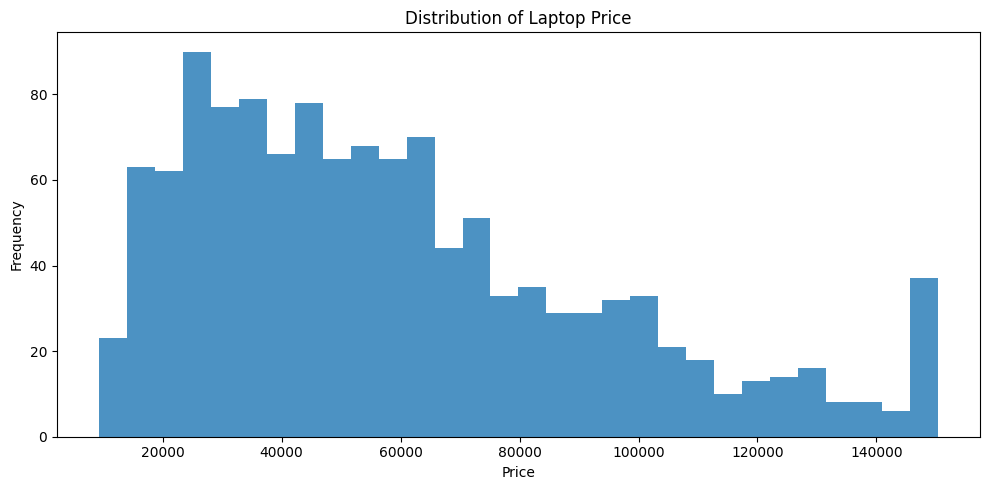

Price skewness: 0.8556


,price
count,"1,243.0000"
mean,"59,737.1652"
std,"34,344.3636"
min,"9,270.7200"
25%,"32,650.2504"
50%,"52,693.9200"
75%,"79,733.5200"
max,"150,358.4244"


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["price"], bins=30, alpha=0.8)
ax.set_title("Distribution of Laptop Price")
ax.set_xlabel("Price")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Price skewness:", round(df["price"].skew(), 4))
display(df["price"].describe().to_frame("price"))

### Target-distribution observation

The target is **right-skewed**, with a skewness of approximately **0.856**. Most observations lie below the upper end of the price range, while a smaller number of relatively expensive laptops extend the right tail.

This matters for the later regression results because a small number of high-price observations can contribute disproportionately to squared error. That is one reason to examine both RMSE and MAE instead of relying on a single error metric.

## 5. Feature distribution analysis

The predictors include a mixture of continuous or multi-valued measurements and binary encoded indicators. The distributions are therefore displayed in two groups.

For the continuous variables, the plots show the empirical spread of quantities such as screen size, RAM, weight, resolution, storage, and PPI. For binary variables, the bars show how frequently each encoded condition occurs in the dataset.

Looking at these distributions helps identify concentration, skewness, sparse categories, and large differences in scale before the regression models are fitted.

In [7]:
feature_columns = [c for c in df.columns if c != "price"]

binary_features = []
continuous_features = []

for col in feature_columns:
    unique_values = df[col].nunique(dropna=False)
    if unique_values <= 2:
        binary_features.append(col)
    else:
        continuous_features.append(col)

print("Continuous / multi-valued features:", len(continuous_features))
print(continuous_features)

print("\nBinary features:", len(binary_features))
print(binary_features)

Continuous / multi-valued features: 7
['inches', 'ram', 'weight', 'res_width', 'res_height', 'storage_gb', 'ppi']

Binary features: 35
['is_ips', 'is_touchscreen', 'has_ssd', 'has_hdd', 'company_Apple', 'company_Asus', 'company_Chuwi', 'company_Dell', 'company_Fujitsu', 'company_Google', 'company_Hp', 'company_Huawei', 'company_Lenovo', 'company_Lg', 'company_Mediacom', 'company_Microsoft', 'company_Msi', 'company_Razer', 'company_Samsung', 'company_Toshiba', 'company_Vero', 'company_Xiaomi', 'typename_Gaming', 'typename_Netbook', 'typename_Notebook', 'typename_Ultrabook', 'typename_Workstation', 'opsys_Chrome Os', 'opsys_Linux', 'opsys_Mac Os X', 'opsys_Macos', 'opsys_No Os', 'opsys_Windows 10', 'opsys_Windows 10 S', 'opsys_Windows 7']


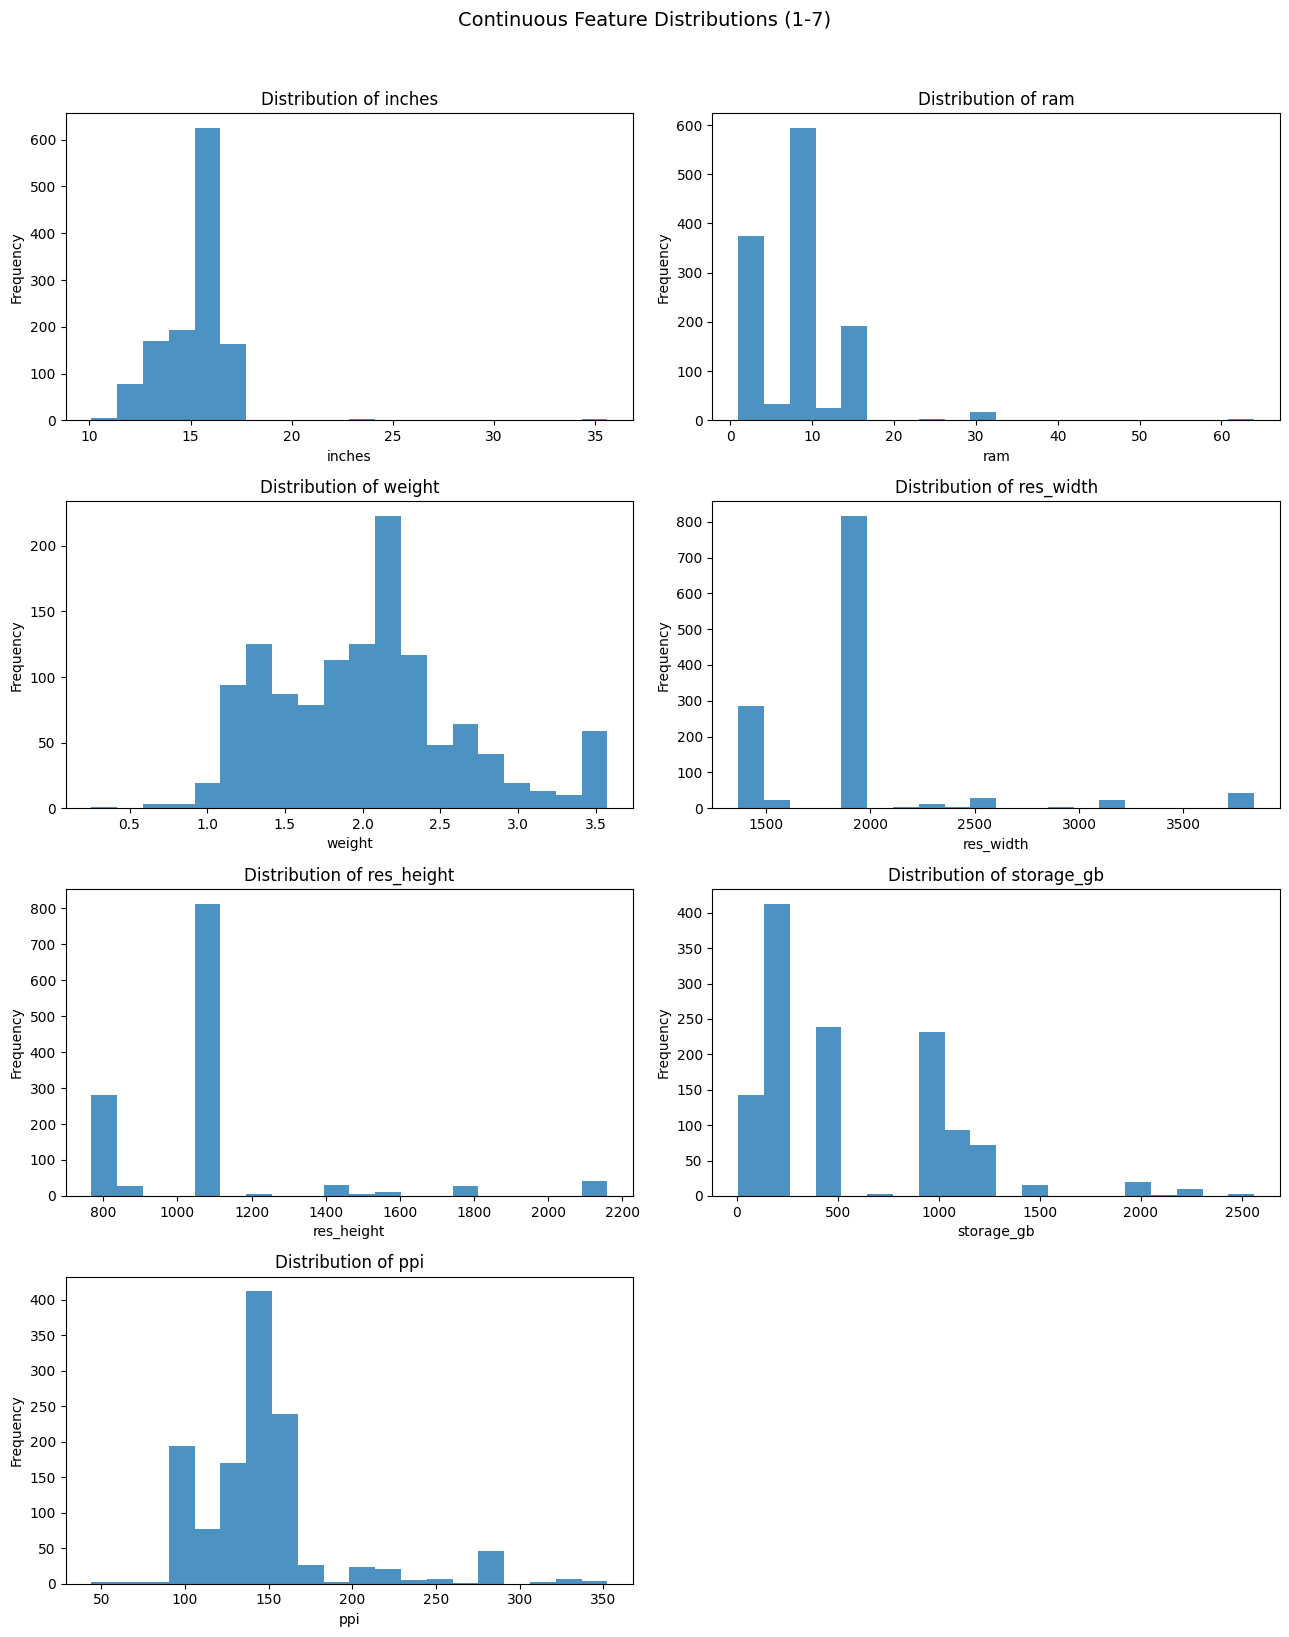

In [8]:
# Continuous feature distributions
group_size = 8

for start in range(0, len(continuous_features), group_size):
    group = continuous_features[start:start + group_size]

    ncols = 2
    nrows = int(np.ceil(len(group) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for ax, col in zip(axes, group):
        ax.hist(df[col], bins=20, alpha=0.8)
        ax.set_title(f"Distribution of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")

    for ax in axes[len(group):]:
        ax.axis("off")

    fig.suptitle(
        f"Continuous Feature Distributions ({start + 1}-{start + len(group)})",
        fontsize=14,
        y=1.02
    )
    plt.tight_layout()
    plt.show()

### Continuous-feature distribution observations

The continuous predictors are not all distributed in the same way. `weight` is comparatively balanced, while variables such as **RAM, screen size, resolution, storage, and PPI are right-skewed**. RAM, for example, has a skewness of approximately **3.63**, and PPI has a skewness of about **1.99**.

Several variables also take values from a relatively small set of common configurations rather than behaving like perfectly continuous measurements. That pattern is expected for laptop specifications and means a large part of the dataset is concentrated around a finite set of market configurations.

These distributions help explain why standardisation is useful and why a flexible functional form may capture relationships that a single straight-line effect cannot.

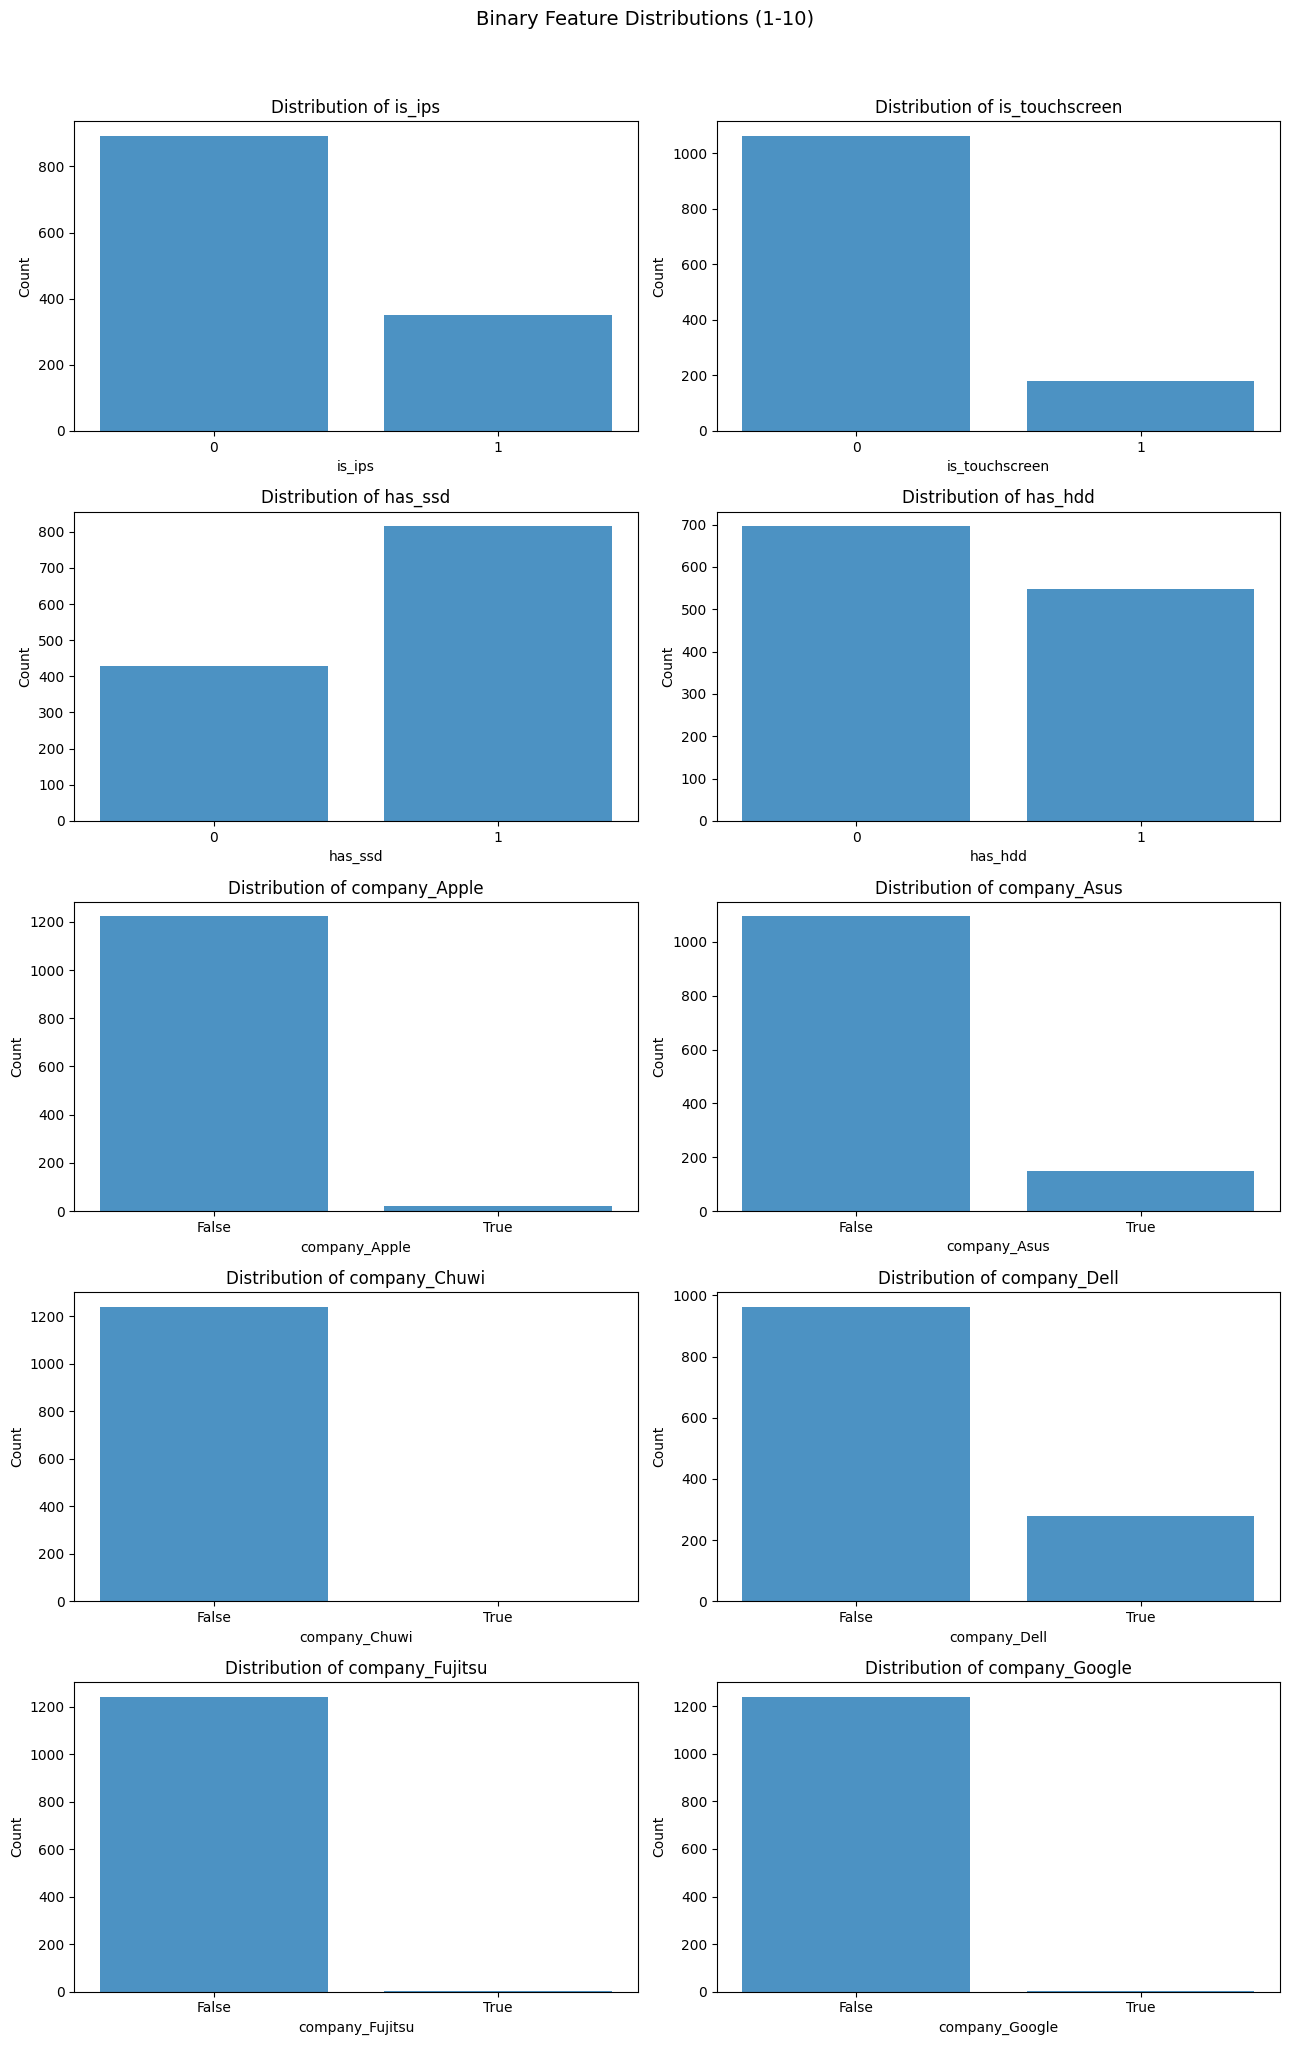

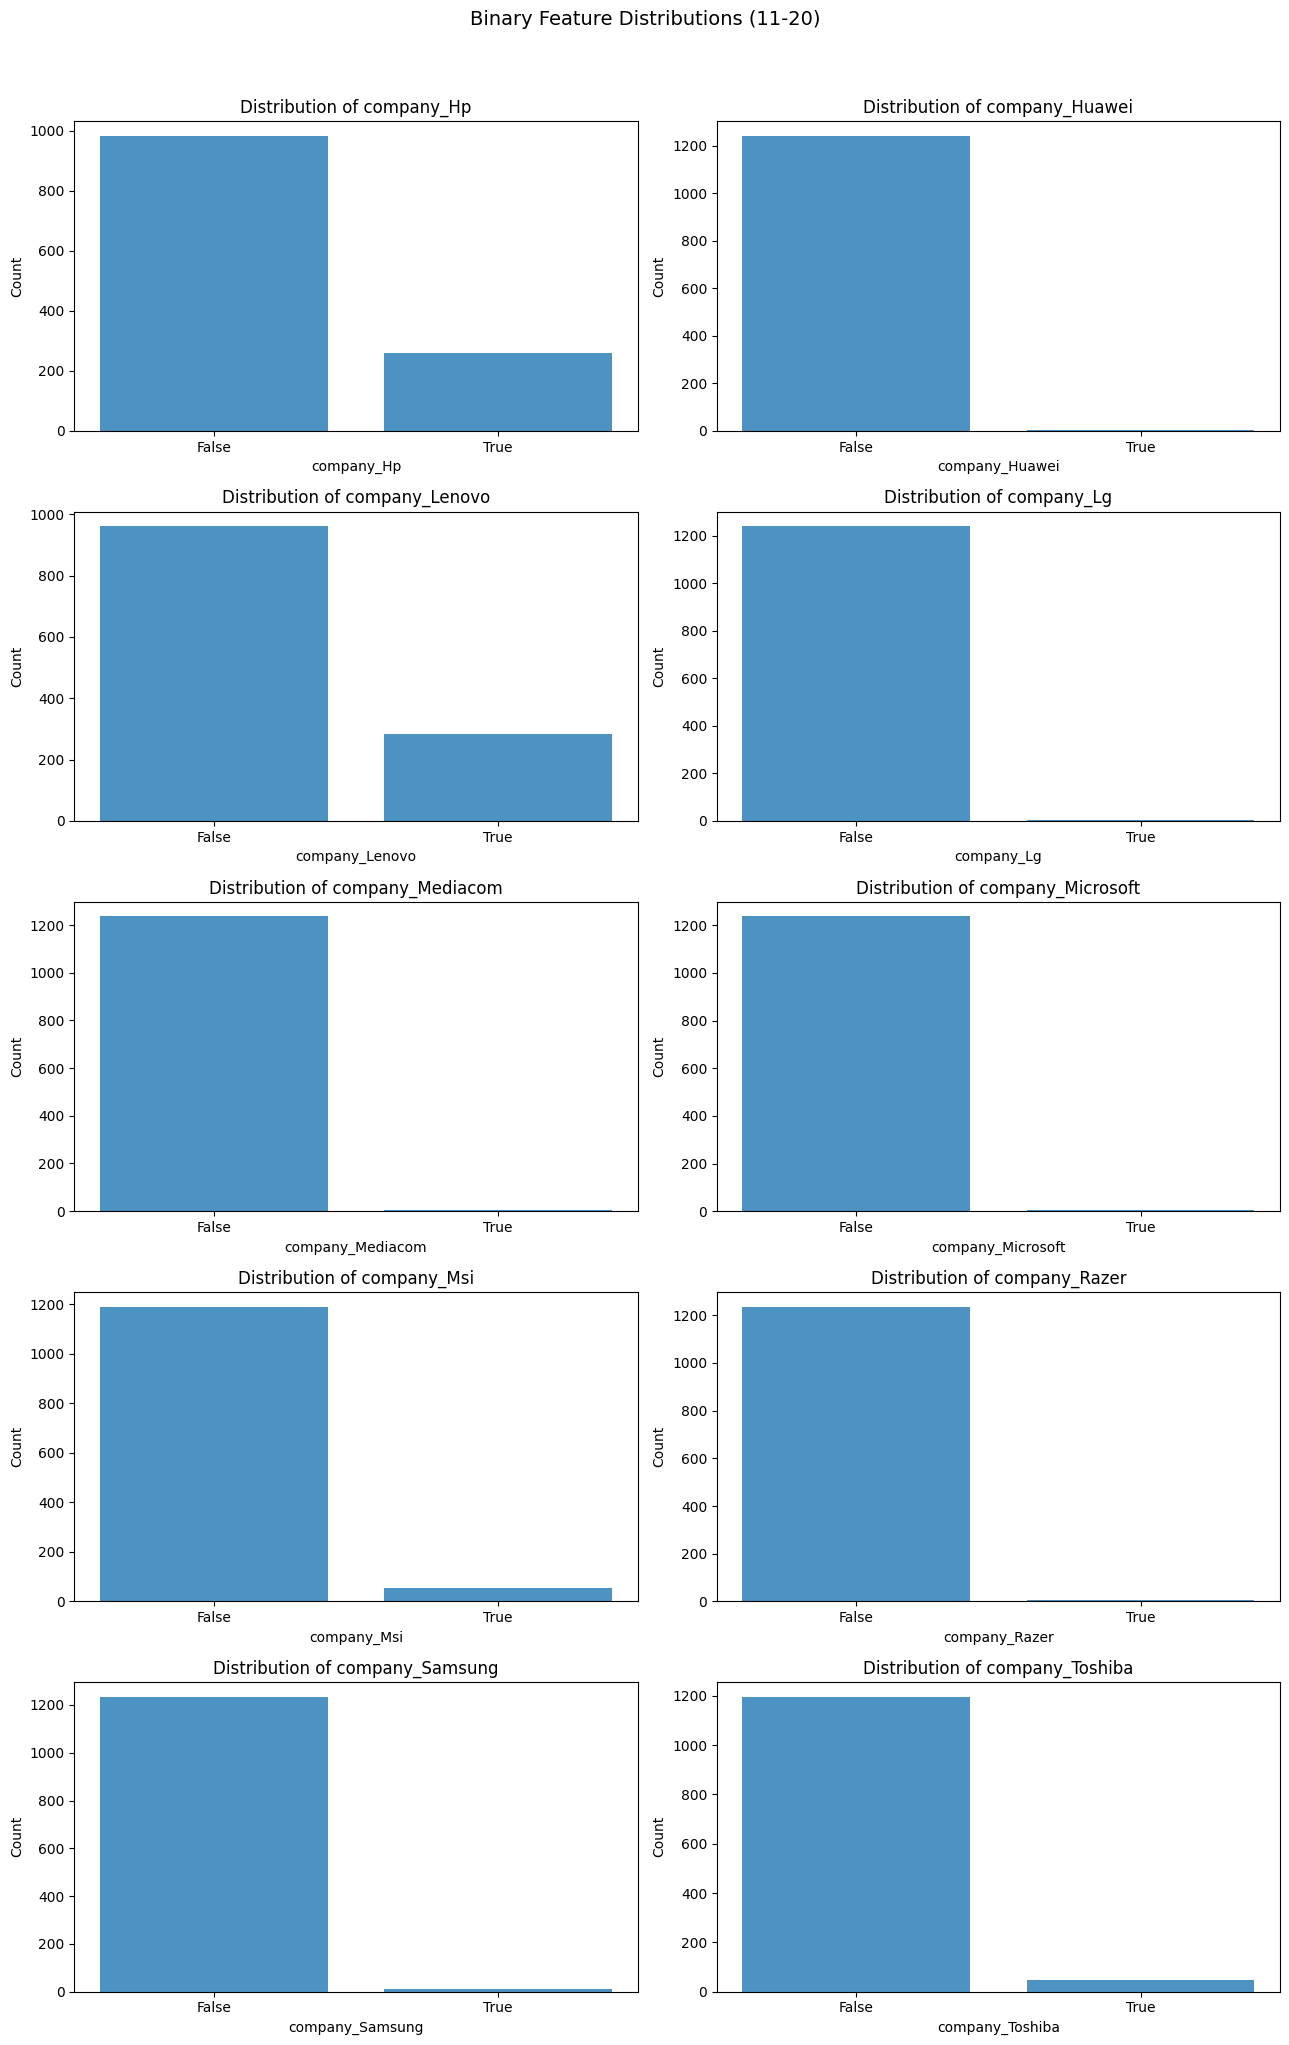

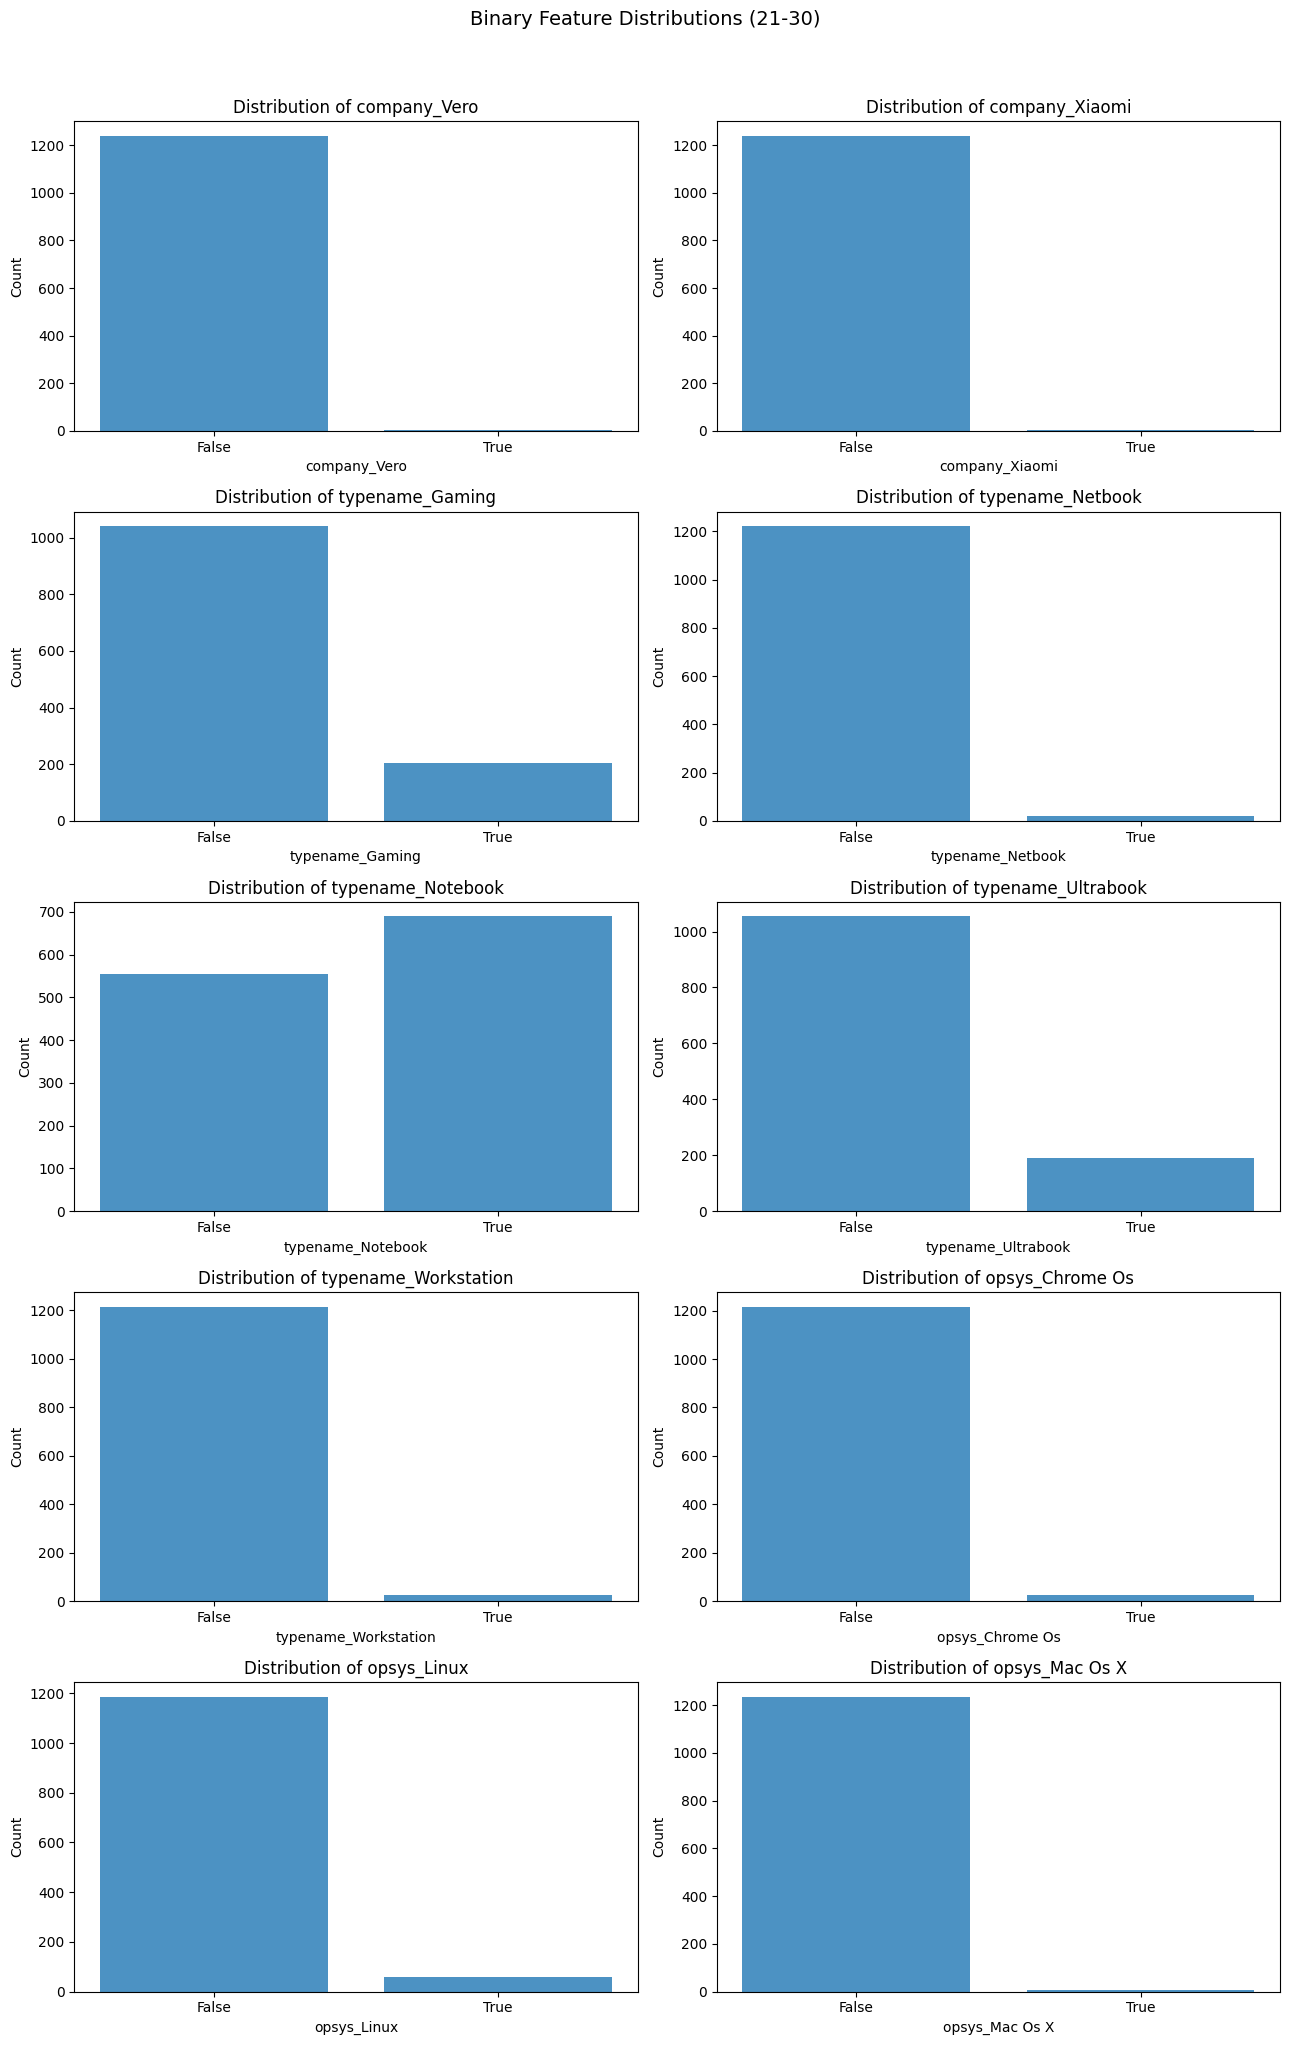

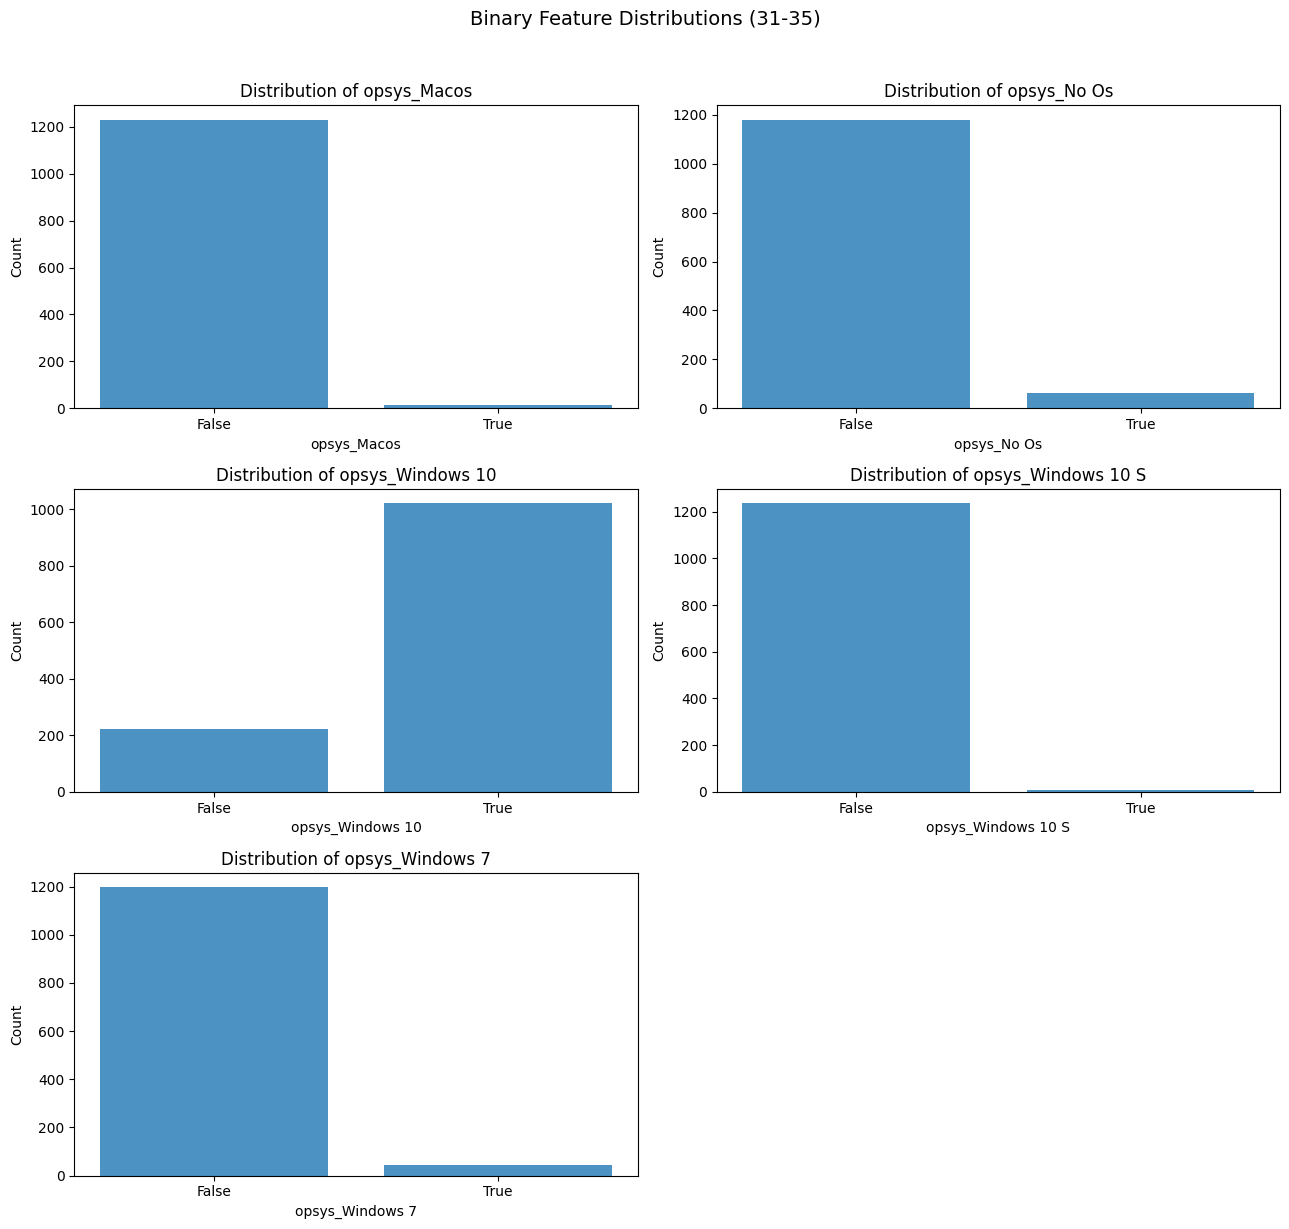

In [9]:
# Binary feature distributions
group_size = 10

for start in range(0, len(binary_features), group_size):
    group = binary_features[start:start + group_size]

    ncols = 2
    nrows = int(np.ceil(len(group) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for ax, col in zip(axes, group):
        counts = df[col].value_counts().sort_index()
        ax.bar(counts.index.astype(str), counts.values, alpha=0.8)
        ax.set_title(f"Distribution of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")

    for ax in axes[len(group):]:
        ax.axis("off")

    fig.suptitle(
        f"Binary Feature Distributions ({start + 1}-{start + len(group)})",
        fontsize=14,
        y=1.02
    )
    plt.tight_layout()
    plt.show()

### Binary-feature distribution observations

The binary indicators are highly imbalanced rather than equally represented. For example, `opsys_Windows 10` is present in about **82.1%** of observations, `has_ssd` in **65.6%**, and `typename_Notebook` in **55.4%**. In contrast, several manufacturer indicators occur in well below 1% of rows.

This imbalance is important when interpreting coefficients and correlations for one-hot variables. A rare category can still have a meaningful fitted coefficient, but that coefficient is supported by relatively few observations and should therefore be interpreted alongside the model's overall behaviour rather than in isolation.

## 6. Correlation analysis

The correlation matrix provides a first view of the linear associations between the numerical predictors and laptop price. It is useful for understanding which features may contribute strongly to a linear model and for spotting groups of predictors that may contain overlapping information.

A correlation coefficient describes linear association, not causation, and a low Pearson correlation does not rule out a useful nonlinear relationship. This distinction becomes important when Polynomial Regression is introduced later.

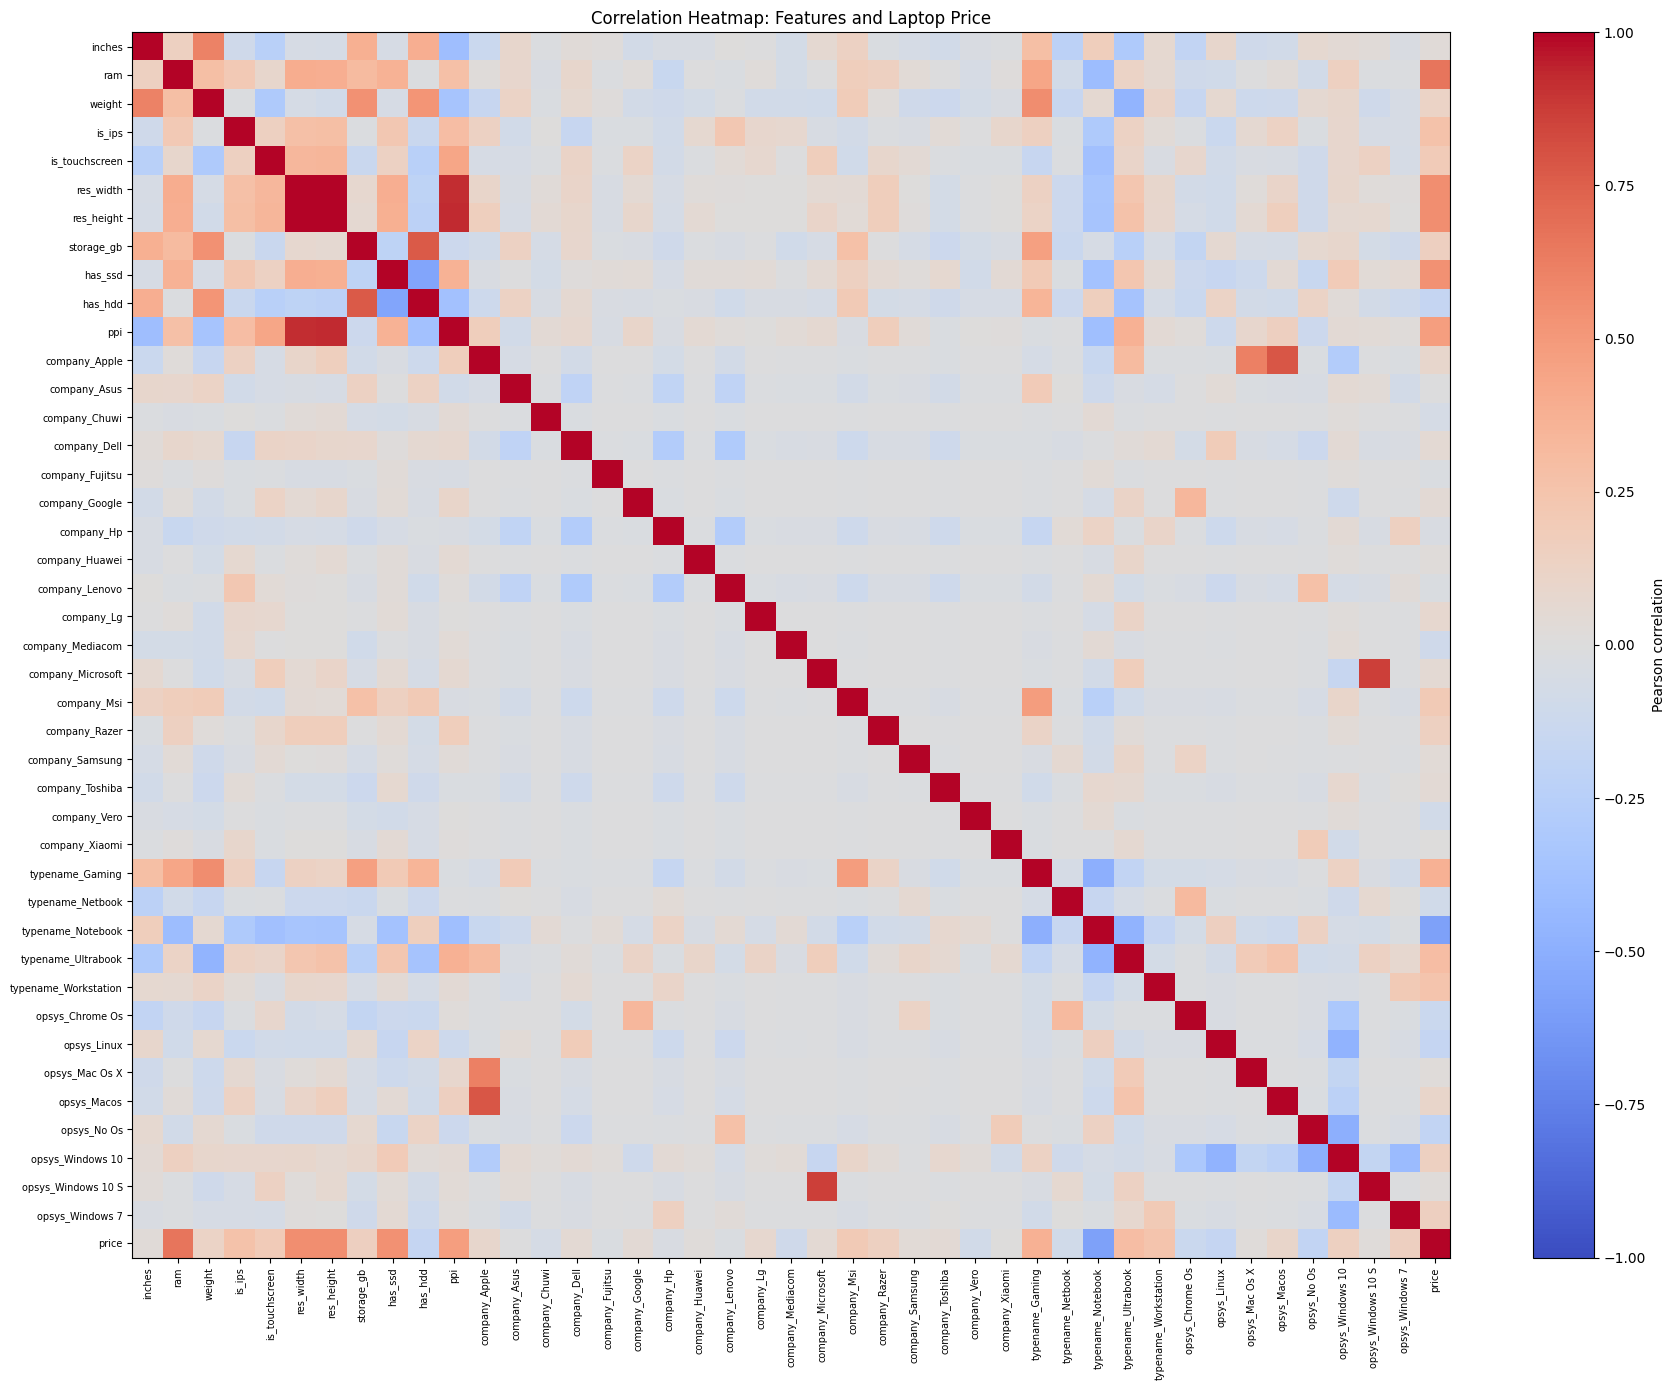

In [10]:
corr_matrix = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(18, 14))
image = ax.imshow(corr_matrix.values, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr_matrix.index, fontsize=7)
ax.set_title("Correlation Heatmap: Features and Laptop Price")

fig.colorbar(image, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()

### Heatmap observation

The heatmap reinforces the numerical ranking: **RAM, screen resolution, SSD presence, and PPI** show noticeably positive association with price, while some laptop-type and operating-system indicators have negative association.

The heatmap also shows why regularisation is worth testing. Several hardware and categorical indicators can carry overlapping information about the type of laptop, so an unregularised model may distribute their effects in a less stable way. Ridge and ElasticNet provide controlled coefficient shrinkage for this situation.

In [11]:
price_correlations = (
    df.drop(columns=["price"])
      .corrwith(df["price"])
      .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("Features ranked by absolute Pearson correlation with price:")
display(price_correlations.to_frame("corr_with_price").head(15))

Features ranked by absolute Pearson correlation with price:


,corr_with_price
ram,0.6591
typename_Notebook,-0.5842
res_width,0.5497
res_height,0.5473
has_ssd,0.5330
ppi,0.4740
typename_Gaming,0.3748
typename_Ultrabook,0.2907
is_ips,0.2653
typename_Workstation,0.2422


### Correlation interpretation

The strongest positive correlations with `price` in the prepared dataset are:

- **RAM:** approximately **0.659**
- **res_width:** approximately **0.550**
- **res_height:** approximately **0.547**
- **has_ssd:** approximately **0.533**
- **PPI:** approximately **0.474**

The strongest negative association is `typename_Notebook`, at approximately **-0.584**. Because the encoded variables represent categories rather than continuous measurements, these correlations should be interpreted as differences in price associated with the presence of a category indicator, not as continuous physical relationships.

The relatively strong correlation between RAM and price provides a useful reason to inspect the RAM-price scatter plot and later test whether allowing curvature improves upon a purely linear specification.

## 7. Feature-target relationship plots

Two continuous variables, **RAM** and **PPI**, are examined against price. RAM represents memory capacity, while PPI represents display pixel density derived during preprocessing.

These plots complement the correlation analysis because they show the actual point cloud rather than reducing the relationship to a single coefficient. We can therefore look for approximate linearity, curvature, clusters, and changes in spread.

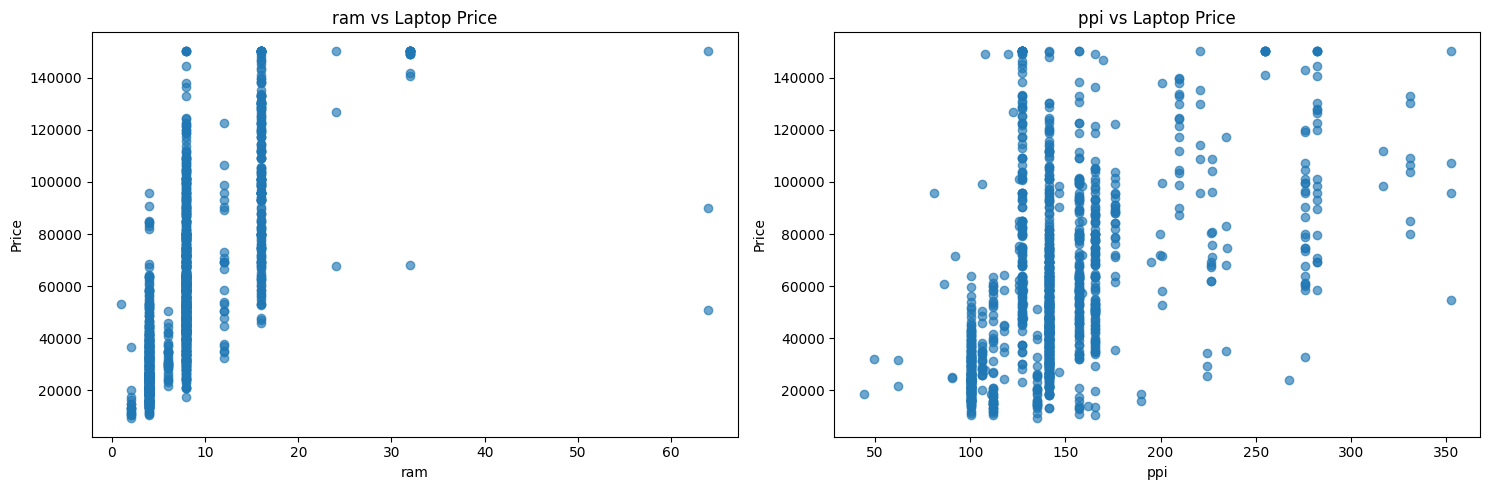

In [12]:
relationship_features = ["ram", "ppi"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, feature in zip(axes, relationship_features):
    ax.scatter(df[feature], df["price"], alpha=0.65)
    ax.set_title(f"{feature} vs Laptop Price")
    ax.set_xlabel(feature)
    ax.set_ylabel("Price")

plt.tight_layout()
plt.show()

### Scatter-plot observation

The RAM scatter plot shows a clear upward trend, but the points form several vertical bands because RAM is recorded in a limited set of standard capacities. Within a single RAM value, price still varies substantially, showing that other specifications and categories contribute important additional information.

The PPI scatter plot is more diffuse. Higher PPI values are generally associated with higher prices, but the relationship is weaker than the RAM relationship and the point cloud has substantial spread. This supports using multiple predictors rather than treating any single display or memory feature as sufficient for price prediction.

### Relationship-plot observations

**RAM vs Price:** RAM has a correlation of approximately **0.659** with price, making it the strongest single continuous predictor in this dataset by Pearson correlation. The relationship is clearly positive, but the observations do not collapse onto a single straight line. Different laptop categories and configurations can have very different prices even at similar RAM values.

**PPI vs Price:** PPI has a weaker but still positive correlation of approximately **0.474**. The relationship is more dispersed than the RAM relationship, indicating that display pixel density alone does not explain a large portion of the variation in price.

Together, these plots suggest that linear relationships contain substantial predictive signal, but they also leave room for nonlinear effects and interactions among laptop specifications.

## 8. Separate predictors and target

The regression target is:

$$
y = price
$$

All remaining columns form the predictor matrix:

$$
X = [x_1,x_2,\ldots,x_p]
$$

The boolean indicator columns are converted to `0` and `1` so every predictor has an explicit numerical representation before it enters the estimators. No additional target-derived feature is created at this stage.

In [13]:
X = df.drop(columns=["price"]).copy()
y = df["price"].copy()

bool_columns = X.select_dtypes(include=["bool"]).columns.tolist()
if bool_columns:
    X[bool_columns] = X[bool_columns].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of boolean columns converted:", len(bool_columns))

display(X.head())

X shape: (1243, 42)
y shape: (1243,)
Number of boolean columns converted: 31


,inches,ram,weight,is_ips,is_touchscreen,res_width,res_height,storage_gb,has_ssd,has_hdd,ppi,company_Apple,company_Asus,company_Chuwi,company_Dell,company_Fujitsu,company_Google,company_Hp,company_Huawei,company_Lenovo,company_Lg,company_Mediacom,company_Microsoft,company_Msi,company_Razer,company_Samsung,company_Toshiba,company_Vero,company_Xiaomi,typename_Gaming,typename_Netbook,typename_Notebook,typename_Ultrabook,typename_Workstation,opsys_Chrome Os,opsys_Linux,opsys_Mac Os X,opsys_Macos,opsys_No Os,opsys_Windows 10,opsys_Windows 10 S,opsys_Windows 7
0,13.3000,8.0000,1.3700,1,0,2560,1600,128.0000,1,0,226.9830,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
1,13.3000,8.0000,1.3400,0,0,1440,900,128.0000,0,0,127.6779,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
2,15.6000,8.0000,1.8600,0,0,1920,1080,256.0000,1,0,141.2120,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
3,15.4000,16.0000,1.8300,1,0,2880,1800,512.0000,1,0,220.5346,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
4,13.3000,8.0000,1.3700,1,0,2560,1600,256.0000,1,0,226.9830,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0


## 9. Reproducible train/test split

The same train/test partition is reused for all five algorithms so the metric differences come from the modelling methods rather than from different test observations. The split uses **80% of the data for training and 20% for testing**.

Because `price` is continuous, ordinary class-based stratification is not applicable. Instead, the continuous target is divided into five quantile bins only for the purpose of constructing approximately balanced train and test partitions. The original continuous values remain unchanged as the regression target.

In [14]:
target_bins = pd.qcut(y, q=5, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=target_bins
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

split_summary = pd.DataFrame({
    "Train": y_train.describe(),
    "Test": y_test.describe(),
    "Full": y.describe()
})
display(split_summary)

Training samples: 994
Test samples: 249


,Train,Test,Full
count,994.0000,249.0000,"1,243.0000"
mean,"59,807.8711","59,454.9097","59,737.1652"
std,"34,354.5321","34,371.4183","34,344.3636"
min,"10,602.7200","9,270.7200","9,270.7200"
25%,"32,673.9600","32,447.5200","32,650.2504"
50%,"52,693.9200","52,480.8000","52,693.9200"
75%,"79,813.4400","79,653.6000","79,733.5200"
max,"150,358.4244","150,358.4244","150,358.4244"


## 10. Leakage-safe scaling strategy

Scaling is particularly important for Ridge, Lasso, and ElasticNet because their regularisation penalties act directly on coefficient magnitudes. A predictor measured in a much larger numerical unit could otherwise influence the penalty differently from a predictor with a smaller scale.

The `Pipeline` objects place `StandardScaler` before the regression estimator. Consequently, the mean and standard deviation used for standardisation are learned from the training portion only, and the same transformation is then applied to validation or test observations. The same idea remains valid inside cross-validation because each fold fits its own scaler on its own training subset.

The standardisation transformation is

$$
z_j = \frac{x_j-\mu_j}{\sigma_j}
$$

where $\mu_j$ and $\sigma_j$ are calculated from the relevant training data.

In [15]:
def regression_metrics(y_true, y_pred):
    # Return the mandatory regression metrics in one consistent dictionary.
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    # Fit, predict, and calculate the same metrics for every model.
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    metrics = regression_metrics(y_test, predictions)
    metrics["Algorithm"] = name

    return model, predictions, metrics

print("Evaluation helpers ready.")

Evaluation helpers ready.


# 11. Algorithm 1 - Linear Regression

### How Linear Regression works

Linear Regression models the expected target as a weighted sum of the predictors. In vector form, the prediction is

$$
\hat{y}_i = \beta_0 + \sum_{j=1}^{p}\beta_j x_{ij}
$$

where $\beta_0$ is the intercept and $\beta_j$ is the coefficient associated with feature $j$.

The coefficients are estimated by minimising the sum of squared residuals:

$$
\min_{\beta_0,\beta}\;\sum_{i=1}^{n}\left(y_i-\beta_0-\mathbf{x}_i^T\beta\right)^2
$$

The model is a useful baseline because it is simple and interpretable. A positive coefficient indicates that increasing the corresponding standardised predictor is associated with a higher predicted price while holding the other predictors fixed; a negative coefficient indicates the opposite direction.

Because the predictors are standardised inside the pipeline, the coefficient magnitudes are on a common scale, which makes relative coefficient size easier to inspect later.

In [16]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model, linear_pred, linear_metrics = evaluate_model(
    "Linear Regression",
    linear_model,
    X_train, y_train,
    X_test, y_test
)

display(pd.DataFrame([linear_metrics]))

,R2,RMSE,MAE,Algorithm
0,0.6643,"19,874.2983","13,925.1129",Linear Regression


### Linear Regression result and interpretation

The baseline Linear Regression model achieves **$R^2=0.6643$**, with **RMSE = 19,874.30** and **MAE = 13,925.11** on the held-out test set.

An $R^2$ of 0.6643 means that, on this test split, the fitted linear relationship explains about **66.43% of the variance in laptop price relative to a constant-mean predictor**. The RMSE is larger than the MAE, which is expected because RMSE gives greater weight to larger errors.

This result gives us a reference point. The next models will test whether constraining coefficient magnitudes with regularisation can improve generalisation or produce a more stable representation.

# 12. Algorithm 2 - Ridge Regression

### How Ridge Regression works

Ridge Regression extends ordinary least squares by adding an **L2 penalty** on the coefficients. Its objective is

$$
\min_{\beta_0,\beta}\left\{\sum_{i=1}^{n}\left(y_i-\beta_0-\mathbf{x}_i^T\beta\right)^2+\alpha\sum_{j=1}^{p}\beta_j^2\right\}
$$

The parameter $\alpha\ge 0$ controls the strength of the penalty. When $\alpha=0$, the objective reduces to ordinary least squares. As $\alpha$ increases, the fitted coefficients are pushed closer to zero.

The important distinction from feature selection is that Ridge generally **shrinks coefficients without forcing them exactly to zero**. This is especially useful when several predictors carry related information, because spreading the effect across correlated variables can be more stable than allowing an unregularised model to assign large opposing coefficients.

In [17]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_model, ridge_pred, ridge_metrics = evaluate_model(
    "Ridge Regression",
    ridge_model,
    X_train, y_train,
    X_test, y_test
)

display(pd.DataFrame([ridge_metrics]))

,R2,RMSE,MAE,Algorithm
0,0.6652,"19,848.1252","13,895.0261",Ridge Regression


### Ridge Regression result and interpretation

With the baseline setting $\alpha=1$, Ridge achieves **$R^2=0.6652$**, **RMSE = 19,848.13**, and **MAE = 13,895.03**.

Relative to Linear Regression, the change is small but positive on this test split: $R^2$ increases from **0.6643 to 0.6652**, while both RMSE and MAE decrease slightly. This suggests that a small amount of coefficient shrinkage helps the model generalise marginally better than the unregularised baseline.

The improvement is deliberately modest. Regularisation is not automatically beneficial; its value depends on the degree of coefficient instability and redundancy present in the feature set. The later tuning step tests stronger values of $\alpha$ rather than assuming that 1.0 is optimal.

In [54]:
ridge_coefficients = pd.Series(
    ridge_model.named_steps["model"].coef_,
    index=X_train.columns
)

zero_count = int((ridge_coefficients == 0).sum())

non_zero_count = int((ridge_coefficients != 0).sum())

print("Ridge coefficients equal to zero:", zero_count)
print("Ridge coefficients retained:", non_zero_count)

Ridge coefficients equal to zero: 0
Ridge coefficients retained: 42


In [18]:
ridge_coefficient_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": ridge_model.named_steps["model"].coef_
})

ridge_coefficient_table["Absolute_Coefficient"] = (
    ridge_coefficient_table["Coefficient"].abs()
)

ridge_coefficient_table = ridge_coefficient_table.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

display(ridge_coefficient_table)

,Feature,Coefficient,Absolute_Coefficient
1,ram,"11,792.8490","11,792.8490"
5,res_width,"9,956.8051","9,956.8051"
31,typename_Notebook,"-8,194.4990","8,194.4990"
8,has_ssd,"7,495.9728","7,495.9728"
41,opsys_Windows 7,"5,303.8378","5,303.8378"
33,typename_Workstation,"4,699.7198","4,699.7198"
17,company_Hp,"4,236.0346","4,236.0346"
6,res_height,"-4,148.4488","4,148.4488"
19,company_Lenovo,"3,329.2621","3,329.2621"
26,company_Toshiba,"3,229.8857","3,229.8857"


# 13. Algorithm 3 - Lasso Regression

### How Lasso Regression works

Lasso Regression uses an **L1 penalty**, which penalises the absolute value of each coefficient:

$$
\min_{\beta_0,\beta}\left\{\sum_{i=1}^{n}\left(y_i-\beta_0-\mathbf{x}_i^T\beta\right)^2+\alpha\sum_{j=1}^{p}|\beta_j|\right\}
$$

The absolute-value penalty creates a key property: some coefficients can be driven **exactly to zero**. Those zero coefficients mean the corresponding predictors do not contribute to the final fitted model at that regularisation strength.

Lasso therefore performs two jobs simultaneously: it predicts the target and encourages a sparse coefficient vector. The trade-off is controlled by $\alpha$. A small $\alpha$ allows more coefficients to remain active, while a larger $\alpha$ exerts stronger pressure toward zero.

In [19]:
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=100.0, max_iter=20000))
])

lasso_model, lasso_pred, lasso_metrics = evaluate_model(
    "Lasso Regression",
    lasso_model,
    X_train, y_train,
    X_test, y_test
)

display(pd.DataFrame([lasso_metrics]))

,R2,RMSE,MAE,Algorithm
0,0.6644,"19,873.1352","13,946.8751",Lasso Regression


In [20]:
lasso_coefficients = pd.Series(
    lasso_model.named_steps["model"].coef_,
    index=X_train.columns
)

zero_count = int((lasso_coefficients == 0).sum())
non_zero_count = int((lasso_coefficients != 0).sum())

print("Lasso coefficients equal to zero:", zero_count)
print("Lasso coefficients retained:", non_zero_count)

display(
    lasso_coefficients.abs()
    .sort_values(ascending=False)
    .head(15)
    .to_frame("absolute_coefficient")
)

Lasso coefficients equal to zero: 6
Lasso coefficients retained: 36


,absolute_coefficient
ram,"11,878.5592"
typename_Notebook,"7,705.6914"
has_ssd,"7,417.6387"
res_width,"6,704.3255"
typename_Workstation,"4,810.0094"
opsys_Windows 7,"4,599.0307"
company_Hp,"2,990.4710"
company_Toshiba,"2,594.9189"
typename_Ultrabook,"2,174.5572"
company_Razer,"2,069.1688"


### Lasso coefficient interpretation

The coefficient table shows which standardised predictors retain the largest absolute effects after the L1 penalty is applied. In this fitted model, **RAM** has the largest coefficient magnitude, followed by `typename_Notebook`, `has_ssd`, and `res_width`.

The presence of exactly **6 zero coefficients** is the clearest sign of Lasso's sparsity mechanism. The model has removed some predictors from the linear equation entirely at the selected regularisation strength, while retaining 36 predictors with non-zero coefficients.

### Lasso result and sparsity interpretation

The baseline Lasso model reaches **$R^2=0.6644$**, **RMSE = 19,873.14**, and **MAE = 13,946.88**. Its test performance is almost identical to Linear Regression: the difference in $R^2$ is only about **0.0001**.

The coefficient inspection shows **6 coefficients exactly equal to zero** and **36 retained coefficients**. This demonstrates the sparsity effect of the L1 penalty on this dataset.

The strongest retained coefficient magnitude belongs to `ram`, followed by variables such as `typename_Notebook`, `has_ssd`, and `res_width`. Importantly, the existence of zero coefficients does not by itself imply better prediction. Here the predictive metrics remain very close to the ordinary linear baseline, so the main observed benefit is the simpler sparse representation rather than a large increase in test accuracy.

In [52]:
lasso_coefficients = pd.Series(
    lasso_model.named_steps["model"].coef_,
    index=X_train.columns
)

zero_count = int((lasso_coefficients == 0).sum())
non_zero_count = int((lasso_coefficients != 0).sum())

print("Lasso coefficients equal to zero:", zero_count)
print("Lasso coefficients retained:", non_zero_count)


Lasso coefficients equal to zero: 6
Lasso coefficients retained: 36


In [53]:
lasso_coefficient_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lasso_model.named_steps["model"].coef_
})

lasso_coefficient_table["Absolute_Coefficient"] = (
    lasso_coefficient_table["Coefficient"].abs()
)

lasso_coefficient_table = lasso_coefficient_table.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

display(lasso_coefficient_table)

,Feature,Coefficient,Absolute_Coefficient
1,ram,"11,878.5592","11,878.5592"
31,typename_Notebook,"-7,705.6914","7,705.6914"
8,has_ssd,"7,417.6387","7,417.6387"
5,res_width,"6,704.3255","6,704.3255"
33,typename_Workstation,"4,810.0094","4,810.0094"
41,opsys_Windows 7,"4,599.0307","4,599.0307"
17,company_Hp,"2,990.4710","2,990.4710"
26,company_Toshiba,"2,594.9189","2,594.9189"
32,typename_Ultrabook,"2,174.5572","2,174.5572"
24,company_Razer,"2,069.1688","2,069.1688"


# 14. Algorithm 4 - ElasticNet Regression

### How ElasticNet works

ElasticNet combines the L1 and L2 penalties used by Lasso and Ridge. Its objective can be written as

$$
\min_{\beta_0,\beta}\left\{\sum_{i=1}^{n}\left(y_i-\beta_0-\mathbf{x}_i^T\beta\right)^2+\alpha\left[\rho\sum_{j=1}^{p}|\beta_j|+(1-\rho)\sum_{j=1}^{p}\beta_j^2\right]\right\}
$$

where $\alpha$ controls the overall regularisation strength and $\rho$ (the `l1_ratio` in scikit-learn) controls the mixture between L1 and L2 regularisation.

- $\rho=1$ gives a Lasso-like penalty.
- $\rho=0$ gives a Ridge-like penalty.
- Intermediate values combine coefficient shrinkage with the possibility of sparsity.

This combination is useful when predictors are numerous or correlated and we want some of the feature-selection behaviour of Lasso without discarding the stabilising effect of Ridge.

In [22]:
elasticnet_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(
        alpha=0.1,
        l1_ratio=0.5,
        max_iter=20000
    ))
])

elasticnet_model, elasticnet_pred, elasticnet_metrics = evaluate_model(
    "ElasticNet Regression",
    elasticnet_model,
    X_train, y_train,
    X_test, y_test
)

display(pd.DataFrame([elasticnet_metrics]))

,R2,RMSE,MAE,Algorithm
0,0.6694,"19,724.3678","13,995.9798",ElasticNet Regression


### ElasticNet result and interpretation

With the baseline setting $\alpha=0.1$ and `l1_ratio=0.5`, ElasticNet obtains **$R^2=0.6694$**, **RMSE = 19,724.37**, and **MAE = 13,995.98**.

Among the four baseline linear-family models, this is the highest test-set $R^2$. The result suggests that combining L1 and L2 regularisation gives a small predictive advantage on this split. The gain is not large, so tuning both regularisation strength and the L1/L2 mixture is still necessary before treating this configuration as the final ElasticNet model.

# 15. Algorithm 5 - Polynomial Regression

### How Polynomial Regression works

Polynomial Regression keeps a linear regression estimator but expands selected input variables into powers and interactions. For one feature $x$, a degree-$d$ polynomial model has the form

$$
\hat{y}=\beta_0+\beta_1x+\beta_2x^2+\cdots+\beta_d x^d
$$

The model is still **linear in the coefficients** $\beta_0,\beta_1,\ldots,\beta_d$; the nonlinearity comes from the transformed features $x^2,x^3,\ldots$.

In this notebook, polynomial expansion is deliberately restricted to **RAM**. Expanding every encoded categorical column would create a much larger feature space containing many redundant dummy powers and interactions. Restricting the expansion keeps the experiment interpretable while testing whether the strongest continuous predictor benefits from a nonlinear relationship.

The polynomial degree is selected using cross-validation on the training data only.

In [23]:
poly_feature = ["ram"]
other_features = [c for c in X_train.columns if c not in poly_feature]

def make_polynomial_pipeline(degree):
    # Polynomial expansion is restricted to RAM to control dimensionality.
    preprocessing = ColumnTransformer(
        transformers=[
            (
                "ram_polynomial",
                Pipeline([
                    ("poly", PolynomialFeatures(
                        degree=degree,
                        include_bias=False
                    )),
                    ("scaler", StandardScaler())
                ]),
                poly_feature
            ),
            (
                "other_features",
                StandardScaler(),
                other_features
            )
        ],
        remainder="drop"
    )

    return Pipeline([
        ("preprocessing", preprocessing),
        ("model", LinearRegression())
    ])

print("Polynomial model design prepared.")

Polynomial model design prepared.


## Compare polynomial degrees

The polynomial experiment compares degrees **1, 2, 3, and 4**. Degree 1 corresponds to a linear relationship in RAM, while higher degrees allow progressively more curvature.

The comparison uses 5-fold cross-validation on the training data. For each candidate degree, the mean $R^2$ summarises predictive performance across the folds and the standard deviation shows how much that performance changes from fold to fold.

The test set is not used to choose the degree, so it remains available for the final generalisation check.

In [24]:
degree_values = [1, 2, 3, 4]

polynomial_degree_results = []

for degree in degree_values:
    model = make_polynomial_pipeline(degree)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
    polynomial_degree_results.append({
        "degree": degree,
        "Mean CV R2": cv_scores.mean(),
        "Std CV R2": cv_scores.std()
    })

polynomial_degree_df = pd.DataFrame(polynomial_degree_results)
display(polynomial_degree_df)

best_degree = int(polynomial_degree_df.loc[polynomial_degree_df["Mean CV R2"].idxmax(), "degree"])
print("Best polynomial degree (by training CV R2):", best_degree)

,degree,Mean CV R2,Std CV R2
0,1,0.6799,0.0778
1,2,0.6991,0.0573
2,3,0.6556,0.1414
3,4,-6.5631,14.5778


Best polynomial degree (by training CV R2): 2


Retraining the final Polynomial model

The selected degree is retrained on the full training set and evaluated once on the held-out test set, using the same evaluate_model helper as every other algorithm.

In [25]:
polynomial_model = make_polynomial_pipeline(best_degree)

polynomial_model, polynomial_pred, polynomial_metrics = evaluate_model(
    f"Polynomial Regression (degree {best_degree})",
    polynomial_model,
    X_train, y_train,
    X_test, y_test
)

display(pd.DataFrame([polynomial_metrics]))

,R2,RMSE,MAE,Algorithm
0,0.7376,"17,571.0970","13,053.5186",Polynomial Regression (degree 2)


# 16. Algorithm 6 - Decision Tree Regressor

A Decision Tree splits the feature space into axis-aligned regions using threshold rules. Splits are based on variance reduction, not distance, so no feature scaling is required. A moderate max_depth is used as a baseline to control overfitting; the tuning section later searches this hyperparameter properly.

In [26]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor


In [27]:
decision_tree_model = DecisionTreeRegressor(
    max_depth=8,
    random_state=RANDOM_STATE
)

decision_tree_model, decision_tree_pred, decision_tree_metrics = evaluate_model(
"Decision Tree Regressor",
    decision_tree_model,
    X_train, y_train,
    X_test, y_test
)
display(pd.DataFrame([decision_tree_metrics]))

,R2,RMSE,MAE,Algorithm
0,0.6830,"19,311.6616","13,195.4000",Decision Tree Regressor


### Manual Hyperparameter Tuning – max_depth

The max_depth parameter controls the maximum depth of the decision tree. A smaller depth produces a simpler model and may underfit, while a larger depth allows the model to capture more complex patterns but may lead to overfitting. Different values of max_depth are tested and compared using R², RMSE, and MAE.

In [28]:
# Manual tuning of max_depth

depth_values = [3, 5, 7, 8, 10, 15, None]

dt_tuning_results = []

for depth in depth_values:
    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=RANDOM_STATE
    )

    # Train the model with the current depth
    model.fit(X_train, y_train)

    # Predict on test data
    pred = model.predict(X_test)

    # Calculate metrics
    metrics = regression_metrics(y_test, pred)
    metrics["max_depth"] = depth

    dt_tuning_results.append(metrics)

dt_tuning_df = pd.DataFrame(dt_tuning_results)

display(
    dt_tuning_df[
        ["max_depth", "R2", "RMSE", "MAE"]
    ]
)

,max_depth,R2,RMSE,MAE
0,3.0000,0.6663,"19,814.4771","15,596.2533"
1,5.0000,0.6905,"19,082.2527","14,043.9491"
2,7.0000,0.7010,"18,756.5811","13,153.7270"
3,8.0000,0.6830,"19,311.6616","13,195.4000"
4,10.0000,0.6993,"18,809.5254","13,240.0506"
5,15.0000,0.6253,"20,998.7287","14,425.6511"
6,NaN,0.6804,"19,392.8275","13,340.6892"


In [29]:
# Select the depth with the highest R2

best_dt_row = dt_tuning_df.loc[
    dt_tuning_df["R2"].idxmax()
]

best_depth = best_dt_row["max_depth"]

print("Best max_depth:", best_depth)
print("Best R2:", best_dt_row["R2"])
print("RMSE:", best_dt_row["RMSE"])
print("MAE:", best_dt_row["MAE"])

Best max_depth: 7.0
Best R2: 0.7010076196406128
RMSE: 18756.581139613747
MAE: 13153.727033526757


### Retraining the Final Decision Tree

After selecting the best max_depth from the manual tuning results, the Decision Tree is retrained using the selected hyperparameter. The retrained model is then evaluated on the test set to obtain the final performance metrics.

In [30]:
# Retrain the final Decision Tree using the best max_depth

if pd.isna(best_depth):
    best_depth = None
else:
    best_depth = int(best_depth)

decision_tree_tuned = DecisionTreeRegressor(
    max_depth=best_depth,
    random_state=RANDOM_STATE
)

decision_tree_tuned.fit(X_train, y_train)

# Final prediction
decision_tree_tuned_pred = decision_tree_tuned.predict(X_test)

# Final metrics
decision_tree_tuned_metrics = regression_metrics(
    y_test,
    decision_tree_tuned_pred
)

decision_tree_tuned_metrics["max_depth"] = best_depth

display(pd.DataFrame([decision_tree_tuned_metrics]))

,R2,RMSE,MAE,max_depth
0,0.7010,"18,756.5811","13,153.7270",7


# 17. Algorithm 7 - Random Forest Regressor

Random Forest averages many decorrelated trees trained on bootstrap samples, which reduces the variance of a single Decision Tree. It serves as the ensemble baseline for this track. n_estimators is tuned formally later.

In [31]:
random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest_model, random_forest_pred, random_forest_metrics = evaluate_model(
    "Random Forest Regressor",
    random_forest_model,
    X_train, y_train,
    X_test, y_test
)

display(pd.DataFrame([random_forest_metrics]))

,R2,RMSE,MAE,Algorithm
0,0.8100,"14,952.7380","10,421.7488",Random Forest Regressor


### Hyperparameter Tuning using GridSearchCV

The n_estimators hyperparameter determines the number of decision trees in the Random Forest. Increasing the number of trees can improve model stability and reduce variance, but it also increases computational cost. GridSearchCV is used with 5-fold cross-validation to systematically test different values of n_estimators and select the value that gives the best R² score.

In [32]:
from sklearn.model_selection import GridSearchCV

rf_params = {
    "n_estimators": [50, 100, 200, 300, 500]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    rf_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best cross-validation R2:", rf_grid.best_score_)

Best parameters: {'n_estimators': 500}
Best cross-validation R2: 0.8002943606567958


### Retraining the Final Random Forest

The best n_estimators value identified by GridSearchCV is used to retrain the final Random Forest model on the training data. The retrained model is then evaluated on the test set to obtain its final performance metrics.

In [33]:
# Get the best number of estimators
best_n_estimators = rf_grid.best_params_["n_estimators"]

# Create final tuned model
random_forest_tuned = RandomForestRegressor(
    n_estimators=best_n_estimators,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Retrain on training data
random_forest_tuned.fit(X_train, y_train)

# Final prediction
random_forest_tuned_pred = random_forest_tuned.predict(X_test)

# Final metrics
random_forest_tuned_metrics = regression_metrics(
    y_test,
    random_forest_tuned_pred
)

random_forest_tuned_metrics["n_estimators"] = best_n_estimators

display(pd.DataFrame([random_forest_tuned_metrics]))

,R2,RMSE,MAE,n_estimators
0,0.8094,"14,974.6242","10,485.2173",500


# 18. Algorithm 8 - Gradient Boosting Regressor

Gradient Boosting builds trees sequentially, each one correcting the residual errors of the previous ensemble. Performance is sensitive to learning_rate and n_estimators together — a lower learning rate generally needs more estimators to reach the same fit. Both are searched in the tuning section.

In [34]:
gradient_boosting_model = GradientBoostingRegressor(
    learning_rate=0.1,
    n_estimators=200,
    random_state=RANDOM_STATE
)

gradient_boosting_model, gradient_boosting_pred, gradient_boosting_metrics = evaluate_model(
    "Gradient Boosting Regressor",
    gradient_boosting_model,
    X_train, y_train,
    X_test, y_test
)

display(pd.DataFrame([gradient_boosting_metrics]))

,R2,RMSE,MAE,Algorithm
0,0.8121,"14,868.9510","11,025.8598",Gradient Boosting Regressor


### Hyperparameter Tuning using GridSearchCV

Gradient Boosting performance depends on both learning_rate and n_estimators. The learning_rate controls the contribution of each tree, while n_estimators determines the number of boosting stages. A lower learning rate may require more estimators to achieve a similar level of fit. GridSearchCV with 5-fold cross-validation is used to search for the combination that gives the best R² score.

In [35]:
from sklearn.model_selection import GridSearchCV

gb_params = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "n_estimators": [100, 200, 300, 500]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
    gb_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best parameters:", gb_grid.best_params_)
print("Best cross-validation R2:", gb_grid.best_score_)

Best parameters: {'learning_rate': 0.1, 'n_estimators': 200}
Best cross-validation R2: 0.796672586697379


### Retraining the Final Gradient Boosting Model

The best combination of learning_rate and n_estimators identified by GridSearchCV is used to retrain the final Gradient Boosting Regressor on the training data. The retrained model is then evaluated on the test set to obtain its final performance metrics.

In [36]:
# Get best parameters
best_gb_params = gb_grid.best_params_

# Create final tuned model
gradient_boosting_tuned = GradientBoostingRegressor(
    learning_rate=best_gb_params["learning_rate"],
    n_estimators=best_gb_params["n_estimators"],
    random_state=RANDOM_STATE
)

# Retrain on training data
gradient_boosting_tuned.fit(X_train, y_train)

# Final prediction
gradient_boosting_tuned_pred = gradient_boosting_tuned.predict(X_test)

# Final metrics
gradient_boosting_tuned_metrics = regression_metrics(
    y_test,
    gradient_boosting_tuned_pred
)

gradient_boosting_tuned_metrics["learning_rate"] = best_gb_params["learning_rate"]
gradient_boosting_tuned_metrics["n_estimators"] = best_gb_params["n_estimators"]

display(pd.DataFrame([gradient_boosting_tuned_metrics]))

,R2,RMSE,MAE,learning_rate,n_estimators
0,0.8121,"14,868.9510","11,025.8598",0.1000,200


# 19. Algorithm 9 - Support Vector Regressor (SVR)

SVR fits a margin-based boundary in (kernel-transformed) feature space. Because it is distance-sensitive, the same leakage-safe Pipeline([("scaler", ...), ("model", ...)]) pattern used for Ridge/Lasso/ElasticNet is reused here so the scaler is fit on training folds only.

In [37]:
svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(C=1.0, kernel="rbf"))
])

svr_model, svr_pred, svr_metrics = evaluate_model(
    "Support Vector Regressor",
    svr_model,
    X_train, y_train,
    X_test, y_test
)

display(pd.DataFrame([svr_metrics]))

,R2,RMSE,MAE,Algorithm
0,-0.0374,"34,938.1703","27,028.4061",Support Vector Regressor


### Manual Hyperparameter Tuning – C and kernel

The C parameter controls the trade-off between model complexity and the tolerance for prediction errors, while the kernel determines the type of transformation used by SVR. Since SVR is sensitive to feature scale, StandardScaler is applied before the SVR model using a Pipeline. Different combinations of C and kernel are manually tested and compared using R², RMSE, and MAE. The combination with the best overall performance is selected for the final model.

In [38]:
# Manual tuning of C and kernel

C_values = [0.1, 1, 10, 100]
kernel_values = ["linear", "rbf", "poly"]

svr_tuning_results = []

for C in C_values:
    for kernel in kernel_values:

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVR(C=C, kernel=kernel))
        ])

        # Train
        model.fit(X_train, y_train)

        # Predict
        pred = model.predict(X_test)

        # Calculate metrics
        metrics = regression_metrics(y_test, pred)
        metrics["C"] = C
        metrics["kernel"] = kernel

        svr_tuning_results.append(metrics)

svr_tuning_df = pd.DataFrame(svr_tuning_results)

display(
    svr_tuning_df[
        ["C", "kernel", "R2", "RMSE", "MAE"]
    ]
)

,C,kernel,R2,RMSE,MAE
0,0.1000,linear,-0.0247,"34,724.0274","26,837.6625"
1,0.1000,rbf,-0.0387,"34,959.8641","27,054.1926"
2,0.1000,poly,-0.0378,"34,945.3849","27,036.7285"
3,1.0000,linear,0.0931,"32,665.8025","25,039.6524"
4,1.0000,rbf,-0.0374,"34,938.1703","27,028.4061"
5,1.0000,poly,-0.0305,"34,820.6770","26,887.4355"
6,10.0000,linear,0.5461,"23,111.2954","16,942.4495"
7,10.0000,rbf,-0.0219,"34,676.1028","26,772.4579"
8,10.0000,poly,-0.0006,"34,313.2511","26,264.9911"
9,100.0000,linear,0.6643,"19,875.5248","13,796.4036"


In [39]:
# Select the best combination based on highest R2

best_svr_row = svr_tuning_df.loc[
    svr_tuning_df["R2"].idxmax()
]

best_C = best_svr_row["C"]
best_kernel = best_svr_row["kernel"]

print("Best C:", best_C)
print("Best kernel:", best_kernel)
print("Best R2:", best_svr_row["R2"])
print("RMSE:", best_svr_row["RMSE"])
print("MAE:", best_svr_row["MAE"])

Best C: 100.0
Best kernel: linear
Best R2: 0.664270138568697
RMSE: 19875.524828671892
MAE: 13796.403552163714


### Retraining the Final SVR

After selecting the best combination of C and kernel, the final SVR model is retrained using the selected hyperparameters. StandardScaler is retained in the Pipeline so that scaling is fitted only on the training data. The retrained model is then evaluated on the test set to obtain its final performance metrics.

In [40]:
# Retrain the final SVR using the best hyperparameters

svr_tuned = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(
        C=best_C,
        kernel=best_kernel
    ))
])

# Retrain on training data
svr_tuned.fit(X_train, y_train)

# Final prediction
svr_tuned_pred = svr_tuned.predict(X_test)

# Final metrics
svr_tuned_metrics = regression_metrics(
    y_test,
    svr_tuned_pred
)

svr_tuned_metrics["C"] = best_C
svr_tuned_metrics["kernel"] = best_kernel

display(pd.DataFrame([svr_tuned_metrics]))

,R2,RMSE,MAE,C,kernel
0,0.6643,"19,875.5248","13,796.4036",100.0000,linear


# 20. Algorithm 10 - K-Nearest Neighbors Regressor

KNN predicts using the average target of the k nearest training points in feature space, so it is highly sensitive to feature scale — a column measured in the hundreds (e.g. resolution width) would otherwise dominate the distance calculation over a column measured in single digits (e.g. RAM in GB). The same scaling pipeline is used here.

In [41]:
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=5))
])

knn_model, knn_pred, knn_metrics = evaluate_model(
    "K-Nearest Neighbors Regressor",
    knn_model,
    X_train, y_train,
    X_test, y_test
)

display(pd.DataFrame([knn_metrics]))

,R2,RMSE,MAE,Algorithm
0,0.6747,"19,565.2328","13,675.3711",K-Nearest Neighbors Regressor


### Manual Hyperparameter Tuning – k

The k parameter represents the number of nearest neighbors used to predict the target value. A small value of k can make the model sensitive to noise, while a large value can make predictions smoother but may cause underfitting. Different values of k are manually tested and compared using R², RMSE, and MAE. The value giving the best overall performance is selected for the final KNN model.

In [42]:
# Manual tuning of k

k_values = [3, 5, 7, 9, 11, 15]

knn_tuning_results = []

for k in k_values:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=k))
    ])

    # Train
    model.fit(X_train, y_train)

    # Predict
    pred = model.predict(X_test)

    # Calculate metrics
    metrics = regression_metrics(y_test, pred)
    metrics["k"] = k

    knn_tuning_results.append(metrics)

knn_tuning_df = pd.DataFrame(knn_tuning_results)

display(
    knn_tuning_df[
        ["k", "R2", "RMSE", "MAE"]
    ]
)

,k,R2,RMSE,MAE
0,3,0.7118,"18,416.5432","12,834.0472"
1,5,0.6747,"19,565.2328","13,675.3711"
2,7,0.6486,"20,333.6781","14,633.2681"
3,9,0.6499,"20,297.8185","14,818.2261"
4,11,0.6547,"20,155.3985","15,090.3081"
5,15,0.6524,"20,224.2498","15,315.0306"


In [43]:
# Select the best k based on highest R2

best_knn_row = knn_tuning_df.loc[
    knn_tuning_df["R2"].idxmax()
]

best_k = int(best_knn_row["k"])

print("Best k:", best_k)
print("Best R2:", best_knn_row["R2"])
print("RMSE:", best_knn_row["RMSE"])
print("MAE:", best_knn_row["MAE"])

Best k: 3
Best R2: 0.711750214286156
RMSE: 18416.54320964519
MAE: 12834.047171084338


### Retraining the Final KNN Model

After selecting the best value of k, the final KNN model is retrained using the selected number of neighbors. StandardScaler is retained in the Pipeline because KNN is distance-sensitive and feature scaling prevents features with larger numerical ranges from dominating the distance calculation. The retrained model is then evaluated on the test set to obtain its final performance metrics.

In [44]:
# Retrain the final KNN using the best k

knn_tuned = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=best_k))
])

# Retrain on training data
knn_tuned.fit(X_train, y_train)

# Final prediction
knn_tuned_pred = knn_tuned.predict(X_test)

# Final metrics
knn_tuned_metrics = regression_metrics(
    y_test,
    knn_tuned_pred
)

knn_tuned_metrics["k"] = best_k

display(pd.DataFrame([knn_tuned_metrics]))

,R2,RMSE,MAE,k
0,0.7118,"18,416.5432","12,834.0472",3


### Effect of Scaling on KNN

KNN uses distances between observations to determine the nearest neighbors. Therefore, feature scaling can affect which observations are considered nearest. The tuned scaled KNN model is compared with an unscaled KNN model using the same value of k to observe the impact of scaling on model performance.

In [45]:
# Compare scaled and unscaled KNN using the best k

knn_unscaled = KNeighborsRegressor(n_neighbors=best_k)

knn_unscaled.fit(X_train, y_train)

knn_unscaled_pred = knn_unscaled.predict(X_test)

knn_unscaled_metrics = regression_metrics(
    y_test,
    knn_unscaled_pred
)

knn_unscaled_metrics["Algorithm"] = "KNN (unscaled features)"
knn_unscaled_metrics["k"] = best_k
display(pd.DataFrame([
    {
        "Algorithm": "KNN (scaled features)",
        **knn_tuned_metrics
    },
    knn_unscaled_metrics
]))

,Algorithm,R2,RMSE,MAE,k
0,KNN (scaled features),0.7118,"18,416.5432","12,834.0472",3
1,KNN (unscaled features),0.7100,"18,472.9273","12,676.5024",3


# 21. Comparative evaluation: all ten algorithms

Each algorithm's final (tuned, where applicable) model is placed in one table, ranked by test-set R², satisfying C2.

In [46]:
model_results = {
    "Linear Regression": linear_metrics,
    "Ridge Regression": ridge_metrics,
    "Lasso Regression": lasso_metrics,
    "ElasticNet Regression": elasticnet_metrics,
    f"Polynomial Regression (degree {best_degree})": polynomial_metrics,
    "Decision Tree Regressor (Tuned)": decision_tree_tuned_metrics,
    "Random Forest Regressor (Tuned)": random_forest_tuned_metrics,
    "Gradient Boosting Regressor (Tuned)": gradient_boosting_tuned_metrics,
    "Support Vector Regressor (Tuned)": svr_tuned_metrics,
    "K-Nearest Neighbors Regressor (Tuned)": knn_tuned_metrics,
}

all_ten_results = pd.DataFrame([
    {"Algorithm": name, "R2": metrics["R2"], "RMSE": metrics["RMSE"], "MAE": metrics["MAE"]}
    for name, metrics in model_results.items()
])

all_ten_results = all_ten_results.sort_values("R2", ascending=False).reset_index(drop=True)
all_ten_results.insert(0, "Rank", np.arange(1, len(all_ten_results) + 1))

display(all_ten_results)
print("Best model overall:", all_ten_results.loc[0, "Algorithm"])

,Rank,Algorithm,R2,RMSE,MAE
0,1,Gradient Boosting Regressor (Tuned),0.8121,"14,868.9510","11,025.8598"
1,2,Random Forest Regressor (Tuned),0.8094,"14,974.6242","10,485.2173"
2,3,Polynomial Regression (degree 2),0.7376,"17,571.0970","13,053.5186"
3,4,K-Nearest Neighbors Regressor (Tuned),0.7118,"18,416.5432","12,834.0472"
4,5,Decision Tree Regressor (Tuned),0.7010,"18,756.5811","13,153.7270"
5,6,ElasticNet Regression,0.6694,"19,724.3678","13,995.9798"
6,7,Ridge Regression,0.6652,"19,848.1252","13,895.0261"
7,8,Lasso Regression,0.6644,"19,873.1352","13,946.8751"
8,9,Linear Regression,0.6643,"19,874.2983","13,925.1129"
9,10,Support Vector Regressor (Tuned),0.6643,"19,875.5248","13,796.4036"


Best model overall: Gradient Boosting Regressor (Tuned)


# 22. 5-fold cross-validation for the two best-performing models

The two top-ranked algorithms from the table above are cross-validated on the training data, satisfying the mandatory 5-fold cross-validated R² requirement.

In [47]:
model_object_map = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model,
    "ElasticNet Regression": elasticnet_model,
    f"Polynomial Regression (degree {best_degree})": polynomial_model,
    "Decision Tree Regressor (Tuned)": decision_tree_tuned,
    "Random Forest Regressor (Tuned)": random_forest_tuned,
    "Gradient Boosting Regressor (Tuned)": gradient_boosting_tuned,
    "Support Vector Regressor (Tuned)": svr_tuned,
    "K-Nearest Neighbors Regressor (Tuned)": knn_tuned,
}

top_two_names = all_ten_results.head(2)["Algorithm"].tolist()
print("Top 2 models:", top_two_names)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
for name in top_two_names:
    estimator = model_object_map[name]
    cv_scores = cross_val_score(estimator, X_train, y_train, cv=cv, scoring="r2", n_jobs=-1)
    cv_rows.append({
        "Algorithm": name,
        "5-Fold CV R2 Mean": cv_scores.mean(),
        "5-Fold CV R2 Std": cv_scores.std(),
        "Fold 1": cv_scores[0], "Fold 2": cv_scores[1], "Fold 3": cv_scores[2],
        "Fold 4": cv_scores[3], "Fold 5": cv_scores[4]
    })

top_two_cv_results = pd.DataFrame(cv_rows)
display(top_two_cv_results)

Top 2 models: ['Gradient Boosting Regressor (Tuned)', 'Random Forest Regressor (Tuned)']


,Algorithm,5-Fold CV R2 Mean,5-Fold CV R2 Std,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
0,Gradient Boosting Regressor (Tuned),0.7934,0.0255,0.8230,0.8153,0.7615,0.8022,0.7651
1,Random Forest Regressor (Tuned),0.7972,0.0236,0.8321,0.7809,0.7673,0.8160,0.7897


# 23. Best-model diagnostics

Predicted-vs-actual and residual plots for the single best model overall, satisfying C4's diagnostic-plot requirement.

In [48]:
best_name = all_ten_results.loc[0, "Algorithm"]
best_model = model_object_map[best_name]
best_predictions = best_model.predict(X_test)
best_residuals = y_test - best_predictions

print("Best model overall:", best_name)
display(pd.DataFrame([{"Algorithm": best_name, **regression_metrics(y_test, best_predictions)}]))

Best model overall: Gradient Boosting Regressor (Tuned)


,Algorithm,R2,RMSE,MAE
0,Gradient Boosting Regressor (Tuned),0.8121,"14,868.9510","11,025.8598"


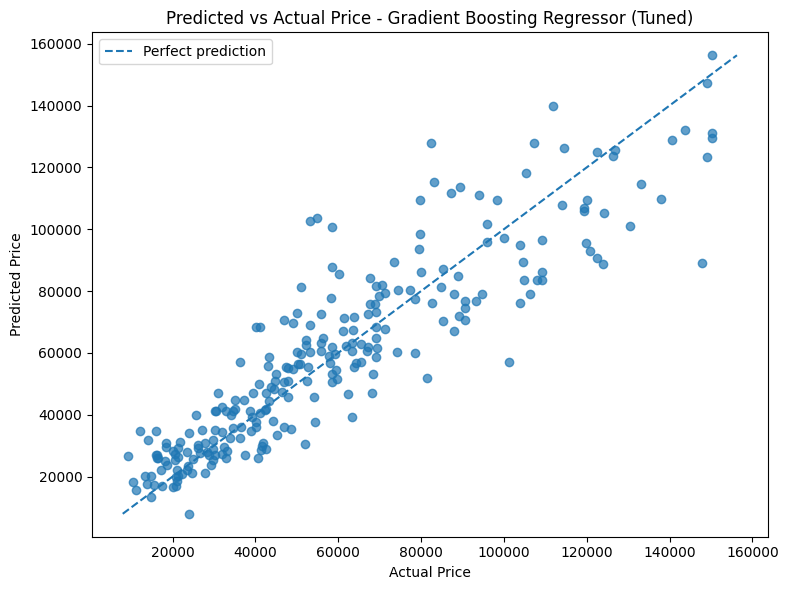

In [49]:
# Predicted vs actual
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, best_predictions, alpha=0.7)

minimum = min(y_test.min(), best_predictions.min())
maximum = max(y_test.max(), best_predictions.max())
ax.plot([minimum, maximum], [minimum, maximum], linestyle="--", label="Perfect prediction")

ax.set_title(f"Predicted vs Actual Price - {best_name}")
ax.set_xlabel("Actual Price")
ax.set_ylabel("Predicted Price")
ax.legend()
plt.tight_layout()
plt.show()

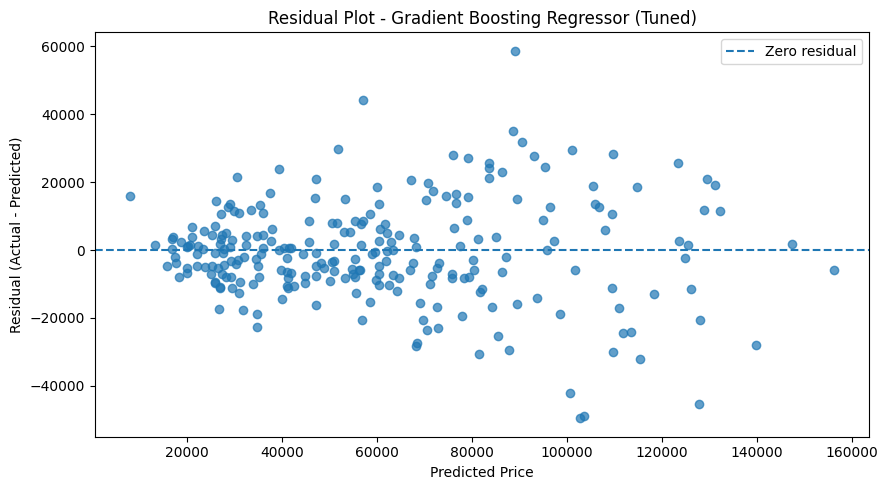

In [50]:
# Residual plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(best_predictions, best_residuals, alpha=0.7)
ax.axhline(0, linestyle="--", label="Zero residual")

ax.set_title(f"Residual Plot - {best_name}")
ax.set_xlabel("Predicted Price")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.legend()
plt.tight_layout()
plt.show()

# 24. Feature importance for a tree-based model

Random Forest (Tuned) is used for the feature-importance plot rather than the single Decision Tree, since averaging across many trees gives a more stable importance estimate.

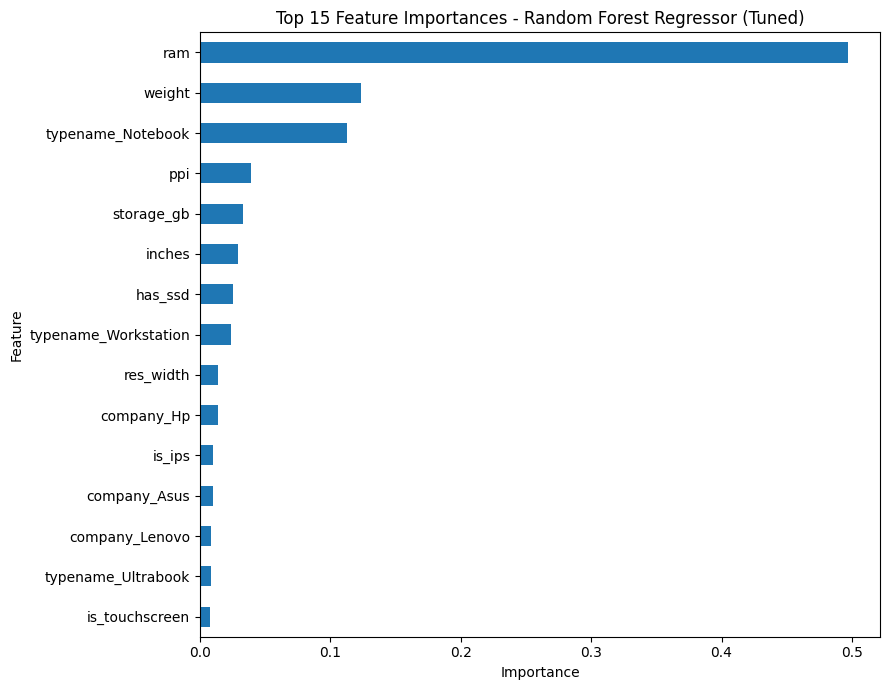

,Importance
ram,0.4967
weight,0.1238
typename_Notebook,0.1128
ppi,0.0389
storage_gb,0.0333
inches,0.0288
has_ssd,0.0253
typename_Workstation,0.0238
res_width,0.0141
company_Hp,0.0135


In [51]:
rf_importances = pd.Series(
    random_forest_tuned.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_features = rf_importances.head(15)

plt.figure(figsize=(9, 7))
top_features.sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances - Random Forest Regressor (Tuned)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(top_features.to_frame(name="Importance"))